# CVLAB Summer Project — Stage 2: Flow Matching to Class Prototypes

**DTD · FGVC-Aircraft | frozen pretrained encoders | FM decision layer**

Stage 2 adds a **flow-matching (FM) layer** on top of the Stage-1 prototype classifier: given a frozen image feature $z$, a small velocity network transports it toward the fixed prototype of its class, and the transported feature is classified with the **identical** cosine/prototype rule as Stage 1. The specification is `_docs/stage_2.pdf`; every design decision left open by it was fixed *before* the first training run in `docs/adr/0007-stage2-design-decisions.md`.

Three heads are compared under identical conditions:

1. **Stage-1 prototype baseline** — no transport (the published Stage-1 numbers, reproduced exactly by this pipeline's $T=0$ integrity guard);
2. **Standard FM** — the velocity network is supervised at random interpolation points along the ideal path;
3. **Rolled-out FM** — the network is trained through the same $T$-step Euler sequence used at inference, with a loss on the final transported feature only.

**Scope and group choices.** Datasets: **DTD + FGVC-Aircraft** — the pair selected on evidence at the end of Stage 1 (ADR 0006). Spec branch: FM toward **image-derived prototypes** (the Stage-1 Option A selection) on ResNet-18 (both datasets) and DINOv2 ViT-S/14 (FGVC-Aircraft). As a clearly-marked **‡ extension** we additionally run the full grid on **CLIP RN50 image features toward the fixed CLIP text prototypes** — Stage 1 established both prototype branches, and the text targets sit across CLIP's image–text modality gap, which makes the transport problem qualitatively different. CLIP‡ FM rows consume labeled images and are therefore *supervised transport*, never "zero-shot"; their reference is the Stage-1 zero-shot number.

**Protocol (inherited from Stage 1, unchanged).** Same feature caches, same committed balanced-subset index files, same class-prototype formula, same seeds, same complete official test split. $K \in \{5, 10, \text{full}\}$; at $K \in \{5,10\}$ the three runs are the three subset seeds (FM initialization fixed), at full they are three FM initialization seeds. Every reported change is $\Delta\mathrm{Acc} = \mathrm{Acc}_{\mathrm{FM}} - \mathrm{Acc}_{\mathrm{baseline}}$ against the Stage-1 baseline of the *identical* setting, paired per seed where pairing is genuine.

## 1 · Environment and configuration

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import json

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from src.utils import load_config

pd.set_option("display.precision", 2)
pd.set_option("display.max_rows", 200)

with open(REPO / "results" / "runtime_summary.json") as f:
    runtime = json.load(f)
print("Runtime:", json.dumps(runtime, indent=2))

cfg = load_config()
s2 = cfg["stage2"]
print("\nStage-2 grid — datasets:", s2["datasets"], "| T values:", s2["T_values"])
print("Branches:", json.dumps(s2["branches"], indent=2))
print("Velocity network:", json.dumps(s2["velocity_net"], indent=2))
print("Training:", json.dumps(s2["training"], indent=2))

Runtime: {
  "python": "3.12.3",
  "platform": "Windows-10-10.0.19045-SP0",
  "torch": "2.9.1+rocm7.2.1",
  "cuda_available": true,
  "device_name": "AMD Radeon RX 7900 XTX",
  "device": "cuda",
  "matmul_ok": true
}

Stage-2 grid — datasets: ['dtd', 'fgvc_aircraft'] | T values: [4, 12]
Branches: {
  "image_prototype": [
    [
      "dtd",
      "resnet18"
    ],
    [
      "fgvc_aircraft",
      "resnet18"
    ],
    [
      "fgvc_aircraft",
      "dinov2_vits14"
    ]
  ],
  "clip_text": [
    [
      "dtd",
      "clip_rn50"
    ],
    [
      "fgvc_aircraft",
      "clip_rn50"
    ]
  ]
}
Velocity network: {
  "hidden": [
    512,
    512
  ],
  "activation": "silu",
  "time_conditioning": "concat_scalar"
}
Training: {
  "optimizer": "adamw",
  "lr": 0.001,
  "weight_decay": 0.0001,
  "batch_size": 64,
  "max_epochs": 200,
  "checkpoint_selection": "min_train_loss"
}


**Hyperparameter provenance.** The velocity network is the specification's suggestion (2 hidden layers of width 512, SiLU, scalar $t$ concatenated to the input feature, output dimension = feature dimension). The training configuration — AdamW, lr $10^{-3}$, weight decay $10^{-4}$, batch 64, 200 epochs — **reuses the Stage-1 linear-probe recipe verbatim**, fixed a priori (ADR 0007 §7); the spec asks for stable training and a fair comparison, not hyperparameter search. **No validation-based checkpointing is used anywhere**: the spec specifies no selection rule for FM, and a per-$T$ validation selection would treat standard FM (whose training is $T$-independent) and rolled-out FM asymmetrically. The a-priori policy was the final-epoch model, with one pre-registered contingency: if any run's final-epoch training loss exceeded $1.05\times$ its own running minimum, the uniform fallback for **all** models would be the minimum-training-loss epoch. **That contingency triggered** — §4 shows the evidence (3 genuine divergences among 135 runs, all rolled-out at K = full, one collapsing to 6% test accuracy) — so every reported model, both modes and both branches, uses its minimum-training-loss epoch. No validation or test data is involved in the selection, and the first (final-epoch) grid's numbers were never published.

Everything runs on the Stage-1 feature caches — no images are touched in Stage 2.

## 2 · Method — exactly as specified

**Standard FM training** (`_docs/stage_2.pdf`). For each training feature $z_i$ with class prototype $p_{y_i}$, sample $t \sim \mathcal{U}(0,1)$, form the interpolation point $z_t = (1-t)\,z_i + t\,p_{y_i}$, and supervise the velocity network on the ideal constant velocity $u_i = p_{y_i} - z_i$:

$$\mathcal{L}_{\mathrm{FM}} = \lVert v_\theta(z_t, t) - u_i \rVert_2^2 .$$

**Inference** (both modes). Start from the test feature $\hat{z}_0 = z$ and apply $T$ Euler steps,

$$\hat{z}_{k+1} = \hat{z}_k + \tfrac{1}{T}\, v_\theta\!\left(\hat{z}_k, \tfrac{k}{T}\right), \qquad k = 0, \dots, T-1, \qquad T \in \{4, 12\},$$

then classify $\hat{z}_T$ with the Stage-1 rule $\hat{y} = \arg\max_c \cos(\hat{z}_T, p_c)$.

**Rolled-out training.** Same network, same $T$-step Euler sequence starting from each *training* feature $\hat{z}_0 = z_i$ — the network is exposed at training time to exactly the self-generated intermediate states it will see at inference — with the loss on the final state only:

$$\mathcal{L}_{\mathrm{roll}} = \lVert \hat{z}_T - p_{y_i} \rVert_2^2 ,$$

backpropagated through the complete sequence of $T$ velocity evaluations. Rolled-out models use the **same $T$ at training and inference** (one model per $T$); standard FM training involves no $T$, so one standard model per setting is trained and evaluated at both $T = 4$ and $T = 12$ — those two rows share one set of weights.

Losses are per-sample squared $L_2$ norms (summed over feature dimensions, averaged over the batch), matching the spec's $\lVert\cdot\rVert_2^2$ exactly.

**One disclosed deviation from the literal spec, fixed a priori (ADR 0007 §3): FM operates on $L_2$-normalized features.** $\hat{z}_0 = z / \lVert z \rVert$; prototypes are unit-norm by construction. The Stage-1 classifier rule is cosine similarity — the normalized sphere is the space in which it acts — while raw frozen features have norms $\approx$ 10–40, so interpolating raw features toward unit-norm prototypes would make the path traverse mostly *scale* rather than class structure. No renormalization is applied between Euler steps (the spec's update is plain Euler); cosine classification normalizes once at the end. With $T=0$ (no transport) the pipeline reduces exactly to Stage 1, which is asserted numerically below.

**Prototypes are identical to Stage 1.** For each $(K, \text{seed})$ they are recomputed with the same formula $\mu_c = \mathrm{normalize}(\tfrac{1}{|S_c|}\sum_{i \in S_c}\mathrm{normalize}(z_i))$ from the same committed subset index files (fingerprint-checked); the CLIP‡ branch uses the cached text prototypes. **Integrity guard:** before any training, the run script asserts for *every* setting that classifying the untransported test features against these prototypes reproduces the Stage-1 baseline accuracy from `runs.csv` to within $10^{-6}$ — all 45 settings (27 image-branch, 18 CLIP‡) passed; the guard below re-executes that check for one setting per branch as a visible demonstration.

In [2]:
import torch
import torch.nn.functional as F

from src.classifiers import PrototypeClassifier
from src.data import training_indices
from src.embeddings import clip_text_path, load_features

runs1 = pd.read_csv(REPO / "results" / "metrics" / "runs.csv")

def t0_check(ds, enc, target, k_shot, seed):
    f = {s: load_features(ds, s, enc) for s in ("train", "test")}
    if target == "image_prototype":
        idx = training_indices(ds, k_shot, seed, f["train"]["labels"].numpy(),
                               fingerprint=f["train"].get("pool_fingerprint"))
        protos = PrototypeClassifier(cfg["datasets"][ds]["n_classes"]).fit(
            f["train"]["features"][idx], f["train"]["labels"][idx].long()).prototypes
        b = runs1[(runs1.dataset == ds) & (runs1.encoder == enc)
                  & (runs1["head"] == "image_prototype")
                  & (runs1.k_shot == f"{k_shot}shot") & (runs1.seed == seed)]
    else:
        protos = torch.load(clip_text_path(ds), weights_only=True)["text_prototypes"].float()
        b = runs1[(runs1.dataset == ds) & (runs1["head"] == "zeroshot_clip")]
    z = F.normalize(f["test"]["features"].float(), dim=-1)
    acc0 = float(((z @ protos.T).argmax(-1) == f["test"]["labels"]).float().mean())
    expected = float(b["test_acc"].iloc[0])
    status = "OK" if abs(acc0 - expected) < 1e-6 else "MISMATCH"
    print(f"  [{status}] {ds} / {enc} / {target}: T=0 accuracy {100*acc0:.4f}% "
          f"vs Stage-1 baseline {100*expected:.4f}%")
    return status == "OK"

print("T = 0 integrity guard (no transport must reproduce Stage 1 exactly):")
assert t0_check("dtd", "resnet18", "image_prototype", 10, 0)
assert t0_check("fgvc_aircraft", "clip_rn50", "clip_text", 10, 0)

T = 0 integrity guard (no transport must reproduce Stage 1 exactly):
  [OK] dtd / resnet18 / image_prototype: T=0 accuracy 52.3936% vs Stage-1 baseline 52.3936%
  [OK] fgvc_aircraft / clip_rn50 / clip_text: T=0 accuracy 17.0417% vs Stage-1 baseline 17.0417%


#### The two versions ‡: the literal-spec raw-feature grid, run in full

The rationale above — raw-space interpolation toward unit-norm prototypes would spend the model's capacity on scale rather than class structure — is a claim about the learned problem, so we measure it rather than assert it: the **complete grid was run twice**. The published version operates on $L_2$-normalized inputs (ADR 0007 §3); the second version is the **literal-spec formulation** ($\hat{z}_0 = z$, raw frozen features) under the otherwise-identical protocol — same velocity network, recipe, prototypes, committed subsets, all seeds, both T values, both branches, the same min-training-loss checkpoint rule, the same test split. The Stage-1 baselines are identical for both versions (cosine classification is scale-invariant), so the comparison isolates the input-normalization decision completely. Full raw-version artifacts: `runs_stage2_raw.csv`, `summary_stage2_raw.csv`, per-run curves and predictions with a `_raw` suffix — all covered by the repro check.

In [3]:
for name in ("stage2_raw_image_prototype_table.md", "stage2_raw_clip_text_table.md"):
    display(Markdown((REPO / "results" / "metrics" / name).read_text(encoding="utf-8")))

s_raw = pd.read_csv(REPO / "results" / "metrics" / "summary_stage2_raw.csv")
s_norm = pd.read_csv(REPO / "results" / "metrics" / "summary_stage2.csv")
keys = ["dataset", "encoder", "target", "head", "T", "k_shot"]
m = s_raw.merge(s_norm, on=keys, suffixes=("_raw", "_norm"))
d = 100 * (m["mean_acc_norm"] - m["mean_acc_raw"])
n_norm = int((d >= 0).sum())
print(f"Normalized ≥ raw in {n_norm} / {len(m)} grid cells; "
      f"normalized − raw ranges {d.min():+.2f} to {d.max():+.2f} points "
      f"(median {d.median():+.2f}).")
below = int((m["mean_acc_raw"] < m["baseline_mean_raw"]).sum())
print(f"Raw-version cells below their own Stage-1 baseline: {below} / {len(m)}.")

import json as _json
raw_curves = sorted((REPO / "results" / "artifacts" / "curves_stage2").glob("*_raw.json"))
bad = sum(1 for p in raw_curves
          if (lambda h: h[-1] > 1.05 * min(h))(_json.load(open(p))["train_loss"]))
print(f"Raw-version stability (same ADR 0007 §7 criterion, same min-loss "
      f"checkpoint rule): {bad} of {len(raw_curves)} curves exceed 1.05x.")

| Dataset | Encoder | Head | K = 5 | K = 10 | full train split |
|---|---|---|---|---|---|
| DTD | ResNet-18 | Standard FM, T = 4 | 29.93 ± 2.09 (norm -13.88) | 38.10 ± 0.99 (norm -10.59) | 39.80 ± 1.22 (norm -19.45) |
| DTD | ResNet-18 | Standard FM, T = 12 | 33.87 ± 1.44 (norm -10.23) | 40.48 ± 0.86 (norm -8.79) | 43.55 ± 0.97 (norm -16.01) |
| DTD | ResNet-18 | Rolled-out FM, T = 4 | 17.20 ± 0.99 (norm -21.76) | 21.38 ± 0.43 (norm -19.11) | 46.12 ± 0.52 (norm -8.69) |
| DTD | ResNet-18 | Rolled-out FM, T = 12 | 21.37 ± 1.21 (norm -18.10) | 27.22 ± 1.65 (norm -13.53) | 48.39 ± 1.00 (norm -7.22) |
| FGVC-Aircraft | ResNet-18 | Standard FM, T = 4 | 9.33 ± 0.12 (norm -8.26) | 12.23 ± 1.07 (norm -11.53) | 15.05 ± 0.93 (norm -16.62) |
| FGVC-Aircraft | ResNet-18 | Standard FM, T = 12 | 11.35 ± 0.66 (norm -6.35) | 13.01 ± 1.07 (norm -10.81) | 16.10 ± 0.36 (norm -15.77) |
| FGVC-Aircraft | ResNet-18 | Rolled-out FM, T = 4 | 5.46 ± 0.56 (norm -10.41) | 11.09 ± 0.47 (norm -9.54) | 13.44 ± 2.51 (norm -11.72) |
| FGVC-Aircraft | ResNet-18 | Rolled-out FM, T = 12 | 7.79 ± 0.15 (norm -8.07) | 15.73 ± 1.55 (norm -5.50) | 17.50 ± 1.40 (norm -7.84) |
| FGVC-Aircraft | DINOv2 | Standard FM, T = 4 | 24.10 ± 0.74 (norm -9.81) | 28.68 ± 0.94 (norm -14.90) | 34.78 ± 0.46 (norm -22.80) |
| FGVC-Aircraft | DINOv2 | Standard FM, T = 12 | 25.15 ± 0.94 (norm -8.35) | 29.58 ± 0.98 (norm -13.70) | 37.63 ± 0.40 (norm -19.64) |
| FGVC-Aircraft | DINOv2 | Rolled-out FM, T = 4 | 18.30 ± 0.82 (norm -15.57) | 33.54 ± 0.82 (norm -9.71) | 30.07 ± 10.40 (norm -25.29) |
| FGVC-Aircraft | DINOv2 | Rolled-out FM, T = 12 | 24.40 ± 0.27 (norm -9.62) | 40.49 ± 0.86 (norm -3.24) | 32.09 ± 6.12 (norm -22.18) |

**Raw-feature version** of the full Stage-2 grid — the literal-spec formulation (ẑ₀ = z, no input L2-normalization), run under the identical protocol: same velocity network, recipe, prototypes, committed subsets, seeds, checkpoint rule and test split as the published normalized version. Top-1 (%) on the complete official test split; mean ± sample std over the same 3 runs. The parenthesis gives the raw-minus-normalized difference of setting means (negative = the normalized version is better). The Stage-1 baselines are identical for both versions (cosine classification is scale-invariant). The normalized version remains the primary published result (ADR 0007 §3).

| Dataset | Encoder | Head | K = 5 | K = 10 | full train split |
|---|---|---|---|---|---|
| DTD ‡ | CLIP RN50 | Standard FM, T = 4 | 51.37 ± 0.83 (norm +0.57) | 56.05 ± 0.30 (norm -0.37) | 62.00 ± 1.65 (norm -1.03) |
| DTD ‡ | CLIP RN50 | Standard FM, T = 12 | 51.54 ± 0.90 (norm +0.66) | 56.54 ± 0.46 (norm -0.16) | 62.62 ± 1.35 (norm -1.05) |
| DTD ‡ | CLIP RN50 | Rolled-out FM, T = 4 | 48.35 ± 1.45 (norm +0.71) | 55.62 ± 0.44 (norm +1.31) | 64.54 ± 0.48 (norm +1.33) |
| DTD ‡ | CLIP RN50 | Rolled-out FM, T = 12 | 48.35 ± 0.93 (norm +0.50) | 54.88 ± 0.72 (norm +0.14) | 62.30 ± 0.90 (norm +0.73) |
| FGVC-Aircraft ‡ | CLIP RN50 | Standard FM, T = 4 | 18.38 ± 0.26 (norm -0.82) | 21.16 ± 0.79 (norm -0.75) | 24.47 ± 1.80 (norm +0.54) |
| FGVC-Aircraft ‡ | CLIP RN50 | Standard FM, T = 12 | 18.59 ± 0.32 (norm -0.86) | 21.39 ± 0.76 (norm -0.64) | 24.45 ± 1.79 (norm -0.10) |
| FGVC-Aircraft ‡ | CLIP RN50 | Rolled-out FM, T = 4 | 19.19 ± 0.29 (norm +0.69) | 25.29 ± 0.23 (norm +2.25) | 34.69 ± 0.69 (norm +3.20) |
| FGVC-Aircraft ‡ | CLIP RN50 | Rolled-out FM, T = 12 | 19.02 ± 0.92 (norm +0.34) | 24.57 ± 0.23 (norm +1.83) | 33.28 ± 0.38 (norm +4.64) |

**Raw-feature version** of the full Stage-2 grid — the literal-spec formulation (ẑ₀ = z, no input L2-normalization), run under the identical protocol: same velocity network, recipe, prototypes, committed subsets, seeds, checkpoint rule and test split as the published normalized version. Top-1 (%) on the complete official test split; mean ± sample std over the same 3 runs. The parenthesis gives the raw-minus-normalized difference of setting means (negative = the normalized version is better). The Stage-1 baselines are identical for both versions (cosine classification is scale-invariant). The normalized version remains the primary published result (ADR 0007 §3).

Normalized ≥ raw in 45 / 60 grid cells; normalized − raw ranges -4.64 to +25.29 points (median +8.17).
Raw-version cells below their own Stage-1 baseline: 27 / 60.


Raw-version stability (same ADR 0007 §7 criterion, same min-loss checkpoint rule): 33 of 135 curves exceed 1.05x.


The two-version comparison replaces any need to argue the normalization choice from first principles. On the **spec branch the cost of the literal formulation is decisive** — the normalized version is better in every one of the 36 image-prototype cells, mostly by double digits, and raw training is also less stable (more curves trip the §4 criterion, and the raw rolled-out DINOv2 full-split runs carry multi-point spreads). On the **CLIP‡ branch the two versions are nearly equivalent** (differences small and mixed in sign, raw slightly ahead in most rolled-out cells) — consistent with CLIP image features having far more uniform norms, so raw and normalized inputs differ much less there. The normalized version remains the primary published result; the raw version is reported in full for transparency.

## 3 · Classification results

Every number below is loaded from `results/metrics/` (generated programmatically, never typed by hand); the raw per-run accuracies live in `results/metrics/raw/*.npy` and the per-run table in `runs_stage2.csv`, so every claim is independently checkable. $\Delta$ = change vs the Stage-1 baseline of the **identical** setting.

### 3.1 Spec branch — FM toward image-derived prototypes

In [4]:
display(Markdown((REPO / "results" / "metrics" / "stage2_image_prototype_table.md")
                 .read_text(encoding="utf-8")))

| Dataset | Encoder | Head | K = 5 | K = 10 | full train split |
|---|---|---|---|---|---|
| DTD | ResNet-18 | Stage-1 Image prototypes (baseline) | **46.51 ± 0.64** | **53.37 ± 1.04** | 58.78 |
| DTD | ResNet-18 | Standard FM, T = 4 | 43.81 ± 1.35 (Δ -2.70 ± 1.46) | 48.69 ± 0.62 (Δ -4.68 ± 1.61) | 59.26 ± 0.32 (Δ +0.48 ± 0.32) |
| DTD | ResNet-18 | Standard FM, T = 12 | 44.10 ± 1.36 (Δ -2.41 ± 1.36) | 49.27 ± 0.52 (Δ -4.10 ± 1.34) | **59.56 ± 0.11 (Δ +0.78 ± 0.11)** |
| DTD | ResNet-18 | Rolled-out FM, T = 4 | 38.95 ± 0.94 (Δ -7.55 ± 0.75) | 40.50 ± 0.91 (Δ -12.87 ± 0.45) | 54.80 ± 1.17 (Δ -3.97 ± 1.17) |
| DTD | ResNet-18 | Rolled-out FM, T = 12 | 39.47 ± 0.97 (Δ -7.04 ± 0.74) | 40.74 ± 0.52 (Δ -12.62 ± 0.53) | 55.60 ± 0.21 (Δ -3.17 ± 0.21) |
| FGVC-Aircraft | ResNet-18 | Stage-1 Image prototypes (baseline) | 16.04 ± 0.83 | 19.85 ± 0.47 | 25.20 |
| FGVC-Aircraft | ResNet-18 | Standard FM, T = 4 | 17.59 ± 0.66 (Δ +1.55 ± 0.18) | 23.76 ± 0.61 (Δ +3.91 ± 0.77) | 31.67 ± 0.17 (Δ +6.47 ± 0.17) |
| FGVC-Aircraft | ResNet-18 | Standard FM, T = 12 | **17.70 ± 0.79 (Δ +1.66 ± 0.06)** | **23.82 ± 0.65 (Δ +3.97 ± 0.63)** | **31.87 ± 0.14 (Δ +6.67 ± 0.14)** |
| FGVC-Aircraft | ResNet-18 | Rolled-out FM, T = 4 | 15.87 ± 0.73 (Δ -0.17 ± 0.76) | 20.63 ± 0.31 (Δ +0.78 ± 0.45) | 25.16 ± 0.92 (Δ -0.04 ± 0.92) |
| FGVC-Aircraft | ResNet-18 | Rolled-out FM, T = 12 | 15.86 ± 0.72 (Δ -0.18 ± 0.92) | 21.23 ± 1.26 (Δ +1.38 ± 1.04) | 25.34 ± 0.80 (Δ +0.14 ± 0.80) |
| FGVC-Aircraft | DINOv2 | Stage-1 Image prototypes (baseline) | 23.11 ± 1.36 | 27.80 ± 1.17 | 34.41 |
| FGVC-Aircraft | DINOv2 | Standard FM, T = 4 | 33.91 ± 1.44 (Δ +10.80 ± 0.50) | 43.58 ± 0.54 (Δ +15.78 ± 0.84) | **57.59 ± 0.71 (Δ +23.17 ± 0.71)** |
| FGVC-Aircraft | DINOv2 | Standard FM, T = 12 | 33.50 ± 1.40 (Δ +10.39 ± 0.47) | 43.28 ± 0.53 (Δ +15.48 ± 0.74) | 57.28 ± 0.53 (Δ +22.86 ± 0.53) |
| FGVC-Aircraft | DINOv2 | Rolled-out FM, T = 4 | 33.87 ± 1.43 (Δ +10.76 ± 1.22) | 43.25 ± 1.06 (Δ +15.45 ± 1.05) | 55.37 ± 0.14 (Δ +20.95 ± 0.14) |
| FGVC-Aircraft | DINOv2 | Rolled-out FM, T = 12 | **34.02 ± 1.69 (Δ +10.91 ± 1.51)** | **43.73 ± 1.63 (Δ +15.93 ± 1.14)** | 54.28 ± 0.82 (Δ +19.86 ± 0.82) |

Top-1 accuracy (%) on the complete official test split; Δ = change vs the Stage-1 image-prototype baseline of the **identical** setting (same subset indices, seeds and prototypes). K ∈ {5, 10}: mean ± sample std over the 3 subset seeds, Δ paired per seed (mean ± std of per-seed differences). full: 3 FM initialization seeds against the single deterministic full-split baseline, so the Δ spread there measures FM training stochasticity only. The two Standard-FM rows of a setting share one trained network (standard FM training is independent of T; only inference differs). **Bold** marks the best value per column within each dataset–encoder block.

**Per-seed-paired deltas.** At $K \in \{5, 10\}$ the FM run and its baseline share the same committed subset indices and prototypes, so the per-seed difference is matched. On FGVC-Aircraft the pairing pays off exactly as expected — the paired spread is far tighter than the marginal spreads (e.g. Δ ± 0.06 vs marginals ± 0.79/0.83 for standard T = 12 at 5-shot). On DTD the opposite happens: the per-seed deltas *anticorrelate*, and their spread (up to ± 1.6) exceeds the marginal spreads — which subset is drawn changes how much transport hurts more than it changes either accuracy alone. Pairing is reported honestly either way; the table below gives the deltas directly. (At full, the baseline is a single deterministic run; the three FM initialization seeds are compared against that one number, so those deltas are *not* paired and their spread measures FM training stochasticity only. $n = 3$ throughout — no confidence intervals are quoted at this sample size.)

In [5]:
display(Markdown((REPO / "results" / "metrics" / "stage2_paired_delta_table.md")
                 .read_text(encoding="utf-8")))

| Dataset | Encoder | Head | K | Δ per seed (paired) | Seeds favouring FM |
|---|---|---|---|---|---|
| DTD | ResNet-18 | Standard FM, T = 4 | 5 | -2.70 ± 1.46 | 0 / 3 |
| DTD | ResNet-18 | Standard FM, T = 12 | 5 | -2.41 ± 1.36 | 0 / 3 |
| DTD | ResNet-18 | Rolled-out FM, T = 4 | 5 | -7.55 ± 0.75 | 0 / 3 |
| DTD | ResNet-18 | Rolled-out FM, T = 12 | 5 | -7.04 ± 0.74 | 0 / 3 |
| DTD | ResNet-18 | Standard FM, T = 4 | 10 | -4.68 ± 1.61 | 0 / 3 |
| DTD | ResNet-18 | Standard FM, T = 12 | 10 | -4.10 ± 1.34 | 0 / 3 |
| DTD | ResNet-18 | Rolled-out FM, T = 4 | 10 | -12.87 ± 0.45 | 0 / 3 |
| DTD | ResNet-18 | Rolled-out FM, T = 12 | 10 | -12.62 ± 0.53 | 0 / 3 |
| FGVC-Aircraft | ResNet-18 | Standard FM, T = 4 | 5 | +1.55 ± 0.18 | 3 / 3 |
| FGVC-Aircraft | ResNet-18 | Standard FM, T = 12 | 5 | +1.66 ± 0.06 | 3 / 3 |
| FGVC-Aircraft | ResNet-18 | Rolled-out FM, T = 4 | 5 | -0.17 ± 0.76 | 2 / 3 |
| FGVC-Aircraft | ResNet-18 | Rolled-out FM, T = 12 | 5 | -0.18 ± 0.92 | 2 / 3 |
| FGVC-Aircraft | ResNet-18 | Standard FM, T = 4 | 10 | +3.91 ± 0.77 | 3 / 3 |
| FGVC-Aircraft | ResNet-18 | Standard FM, T = 12 | 10 | +3.97 ± 0.63 | 3 / 3 |
| FGVC-Aircraft | ResNet-18 | Rolled-out FM, T = 4 | 10 | +0.78 ± 0.45 | 3 / 3 |
| FGVC-Aircraft | ResNet-18 | Rolled-out FM, T = 12 | 10 | +1.38 ± 1.04 | 3 / 3 |
| FGVC-Aircraft | DINOv2 | Standard FM, T = 4 | 5 | +10.80 ± 0.50 | 3 / 3 |
| FGVC-Aircraft | DINOv2 | Standard FM, T = 12 | 5 | +10.39 ± 0.47 | 3 / 3 |
| FGVC-Aircraft | DINOv2 | Rolled-out FM, T = 4 | 5 | +10.76 ± 1.22 | 3 / 3 |
| FGVC-Aircraft | DINOv2 | Rolled-out FM, T = 12 | 5 | +10.91 ± 1.51 | 3 / 3 |
| FGVC-Aircraft | DINOv2 | Standard FM, T = 4 | 10 | +15.78 ± 0.84 | 3 / 3 |
| FGVC-Aircraft | DINOv2 | Standard FM, T = 12 | 10 | +15.48 ± 0.74 | 3 / 3 |
| FGVC-Aircraft | DINOv2 | Rolled-out FM, T = 4 | 10 | +15.45 ± 1.05 | 3 / 3 |
| FGVC-Aircraft | DINOv2 | Rolled-out FM, T = 12 | 10 | +15.93 ± 1.14 | 3 / 3 |

Mean ± sample std (ddof = 1) of the per-seed difference FM − Stage-1 image-prototype baseline, both computed from identical committed subset indices and prototypes. Positive favours FM. n = 3 seeds; no confidence intervals are quoted at this sample size.

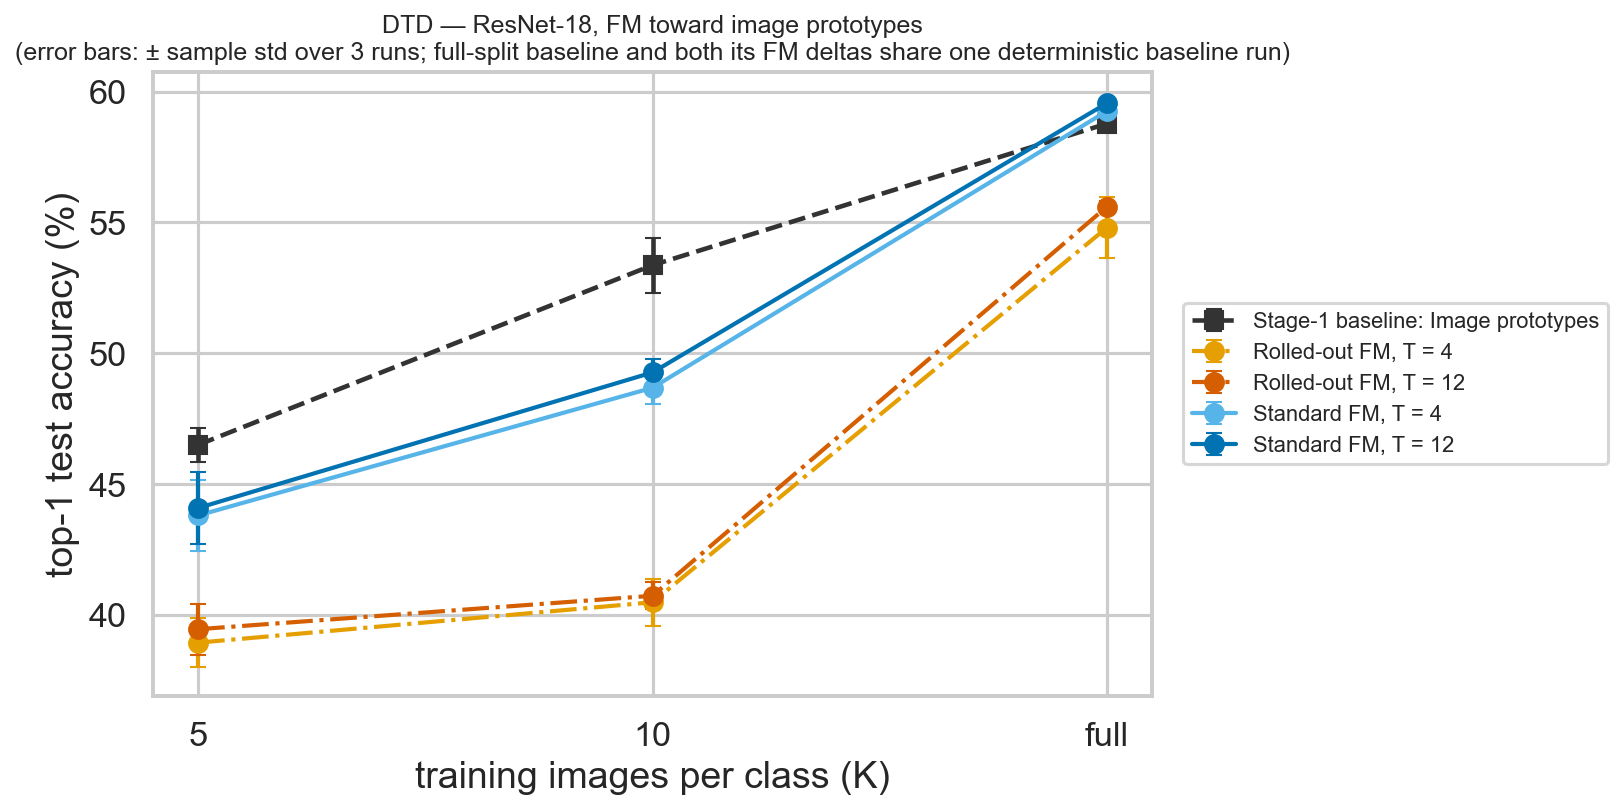

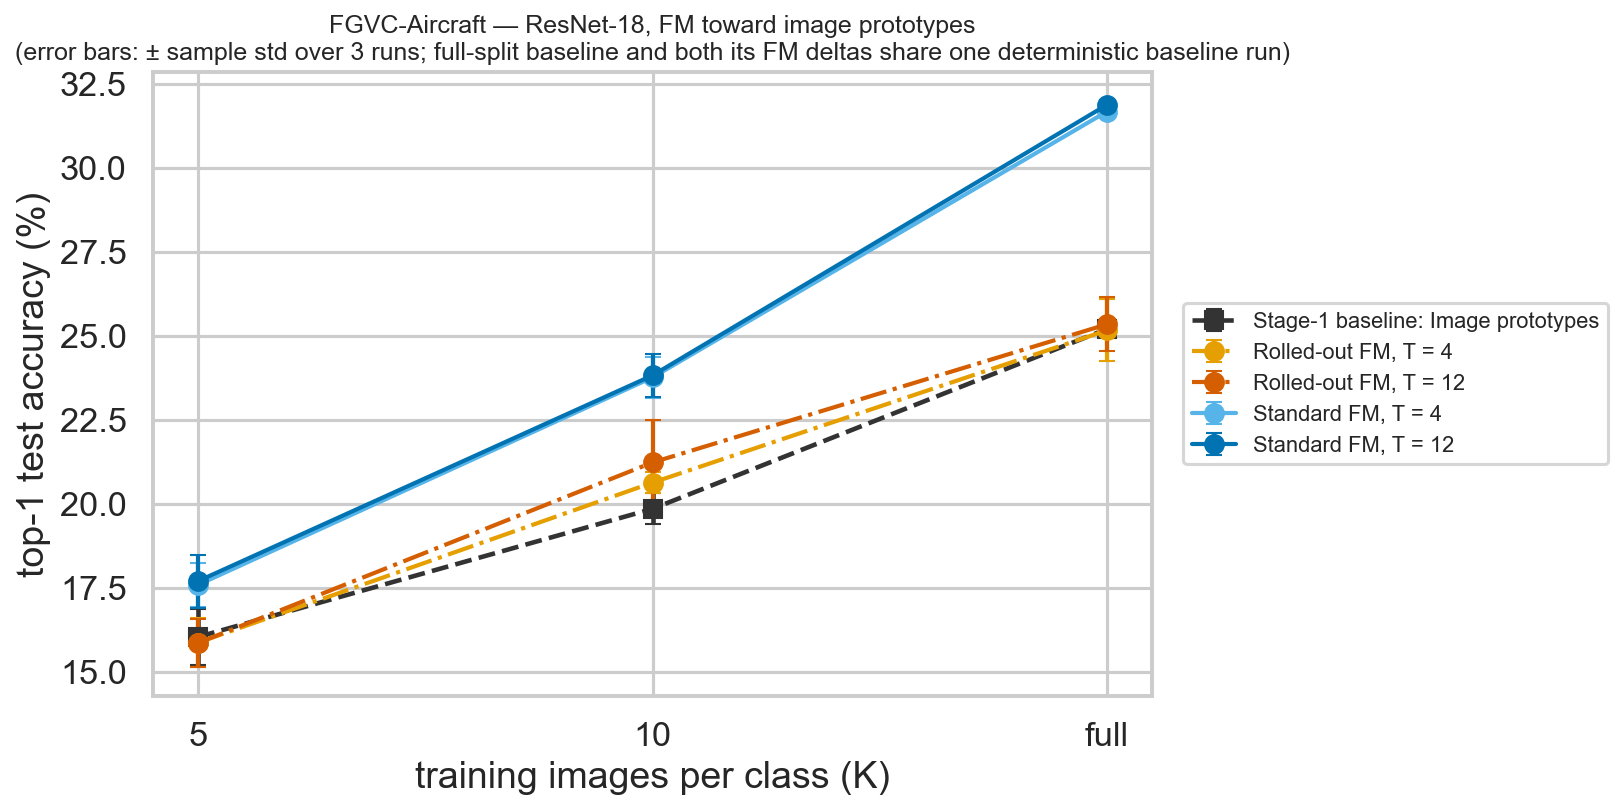

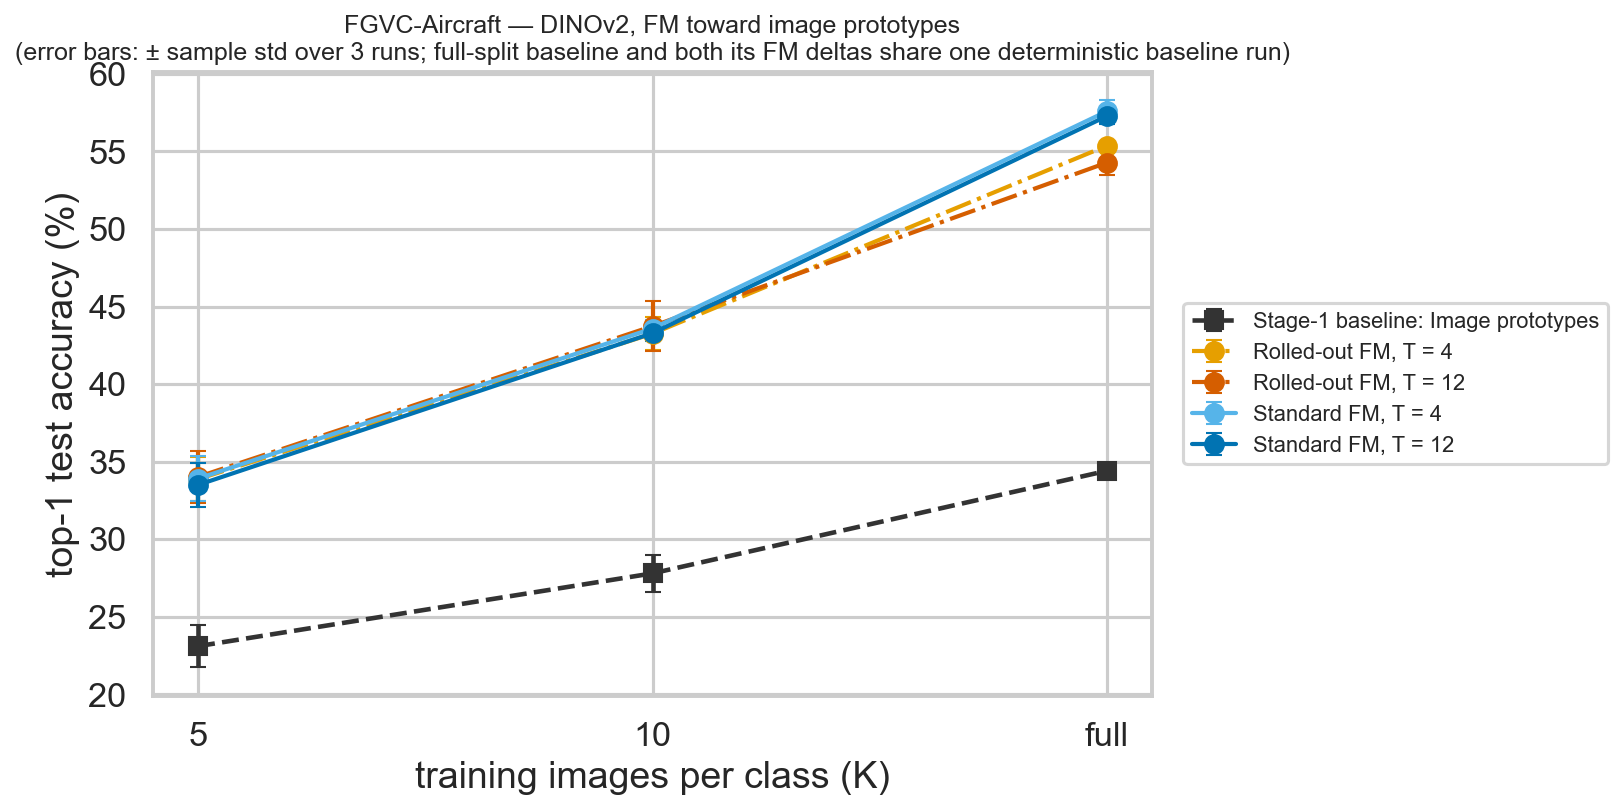

In [6]:
for name in ("stage2_acc_dtd_resnet18_image_prototype.png",
             "stage2_acc_fgvc_aircraft_resnet18_image_prototype.png",
             "stage2_acc_fgvc_aircraft_dinov2_vits14_image_prototype.png"):
    p = REPO / "results" / "figures" / name
    if p.exists():
        display(Image(str(p), width=880))

### 3.2 Extension ‡ — FM on CLIP features toward text prototypes

FM here transports **CLIP RN50 image features** toward the fixed **text** prototypes. Read these rows with care: unlike the Stage-1 zero-shot reference, FM training consumes $K$ labeled images per class, so this is *supervised transport on CLIP features* — never "zero-shot". $\Delta$ therefore answers *"does supervised transport toward text prototypes beat zero-shot classification?"*, **not** *"does the FM layer help?"* — only the image-prototype branch isolates the FM effect, because its baseline uses the identical labeled subset.

In [7]:
display(Markdown((REPO / "results" / "metrics" / "stage2_clip_text_table.md")
                 .read_text(encoding="utf-8")))

| Dataset | Encoder | Head | K = 5 | K = 10 | full train split |
|---|---|---|---|---|---|
| DTD ‡ | CLIP RN50 | Stage-1 Zero-shot CLIP (reference, K-independent) | 39.79 | 39.79 | 39.79 |
| DTD ‡ | CLIP RN50 | Standard FM, T = 4 | 50.80 ± 0.53 (Δ +11.01 ± 0.53) | 56.42 ± 0.84 (Δ +16.63 ± 0.84) | 63.03 ± 0.75 (Δ +23.24 ± 0.75) |
| DTD ‡ | CLIP RN50 | Standard FM, T = 12 | **50.89 ± 0.61 (Δ +11.10 ± 0.61)** | **56.70 ± 0.77 (Δ +16.91 ± 0.77)** | **63.67 ± 0.70 (Δ +23.88 ± 0.70)** |
| DTD ‡ | CLIP RN50 | Rolled-out FM, T = 4 | 47.64 ± 1.24 (Δ +7.85 ± 1.24) | 54.31 ± 0.78 (Δ +14.52 ± 0.78) | 63.21 ± 0.11 (Δ +23.42 ± 0.11) |
| DTD ‡ | CLIP RN50 | Rolled-out FM, T = 12 | 47.85 ± 1.01 (Δ +8.07 ± 1.01) | 54.73 ± 0.94 (Δ +14.95 ± 0.94) | 61.58 ± 1.23 (Δ +21.79 ± 1.23) |
| FGVC-Aircraft ‡ | CLIP RN50 | Stage-1 Zero-shot CLIP (reference, K-independent) | 17.04 | 17.04 | 17.04 |
| FGVC-Aircraft ‡ | CLIP RN50 | Standard FM, T = 4 | 19.20 ± 0.70 (Δ +2.16 ± 0.70) | 21.91 ± 0.62 (Δ +4.87 ± 0.62) | 23.93 ± 0.33 (Δ +6.89 ± 0.33) |
| FGVC-Aircraft ‡ | CLIP RN50 | Standard FM, T = 12 | **19.45 ± 0.82 (Δ +2.41 ± 0.82)** | 22.03 ± 0.36 (Δ +4.99 ± 0.36) | 24.55 ± 0.41 (Δ +7.51 ± 0.41) |
| FGVC-Aircraft ‡ | CLIP RN50 | Rolled-out FM, T = 4 | 18.50 ± 0.72 (Δ +1.46 ± 0.72) | **23.04 ± 0.38 (Δ +6.00 ± 0.38)** | **31.49 ± 1.03 (Δ +14.45 ± 1.03)** |
| FGVC-Aircraft ‡ | CLIP RN50 | Rolled-out FM, T = 12 | 18.68 ± 0.36 (Δ +1.64 ± 0.36) | 22.74 ± 0.45 (Δ +5.70 ± 0.45) | 28.64 ± 0.21 (Δ +11.60 ± 0.21) |

‡ Extension beyond the specification (the spec's Stage-2 branch is the image-prototype branch selected in Stage 1, ADR 0006). FM here transports **CLIP RN50 image features** toward the fixed CLIP **text** prototypes. Unlike the Stage-1 zero-shot reference, FM training consumes K labeled images per class — these rows are *supervised transport on CLIP features*, never "zero-shot". Δ therefore answers "does supervised transport toward text prototypes beat zero-shot classification?", **not** "does the FM layer help?" — only the image-prototype branch isolates the FM effect, because its baseline uses the identical labeled subset. The reference value is a single deterministic run, so Δ carries no pairing; at K ∈ {5, 10} the spread over the 3 subset seeds is reported on the accuracy.

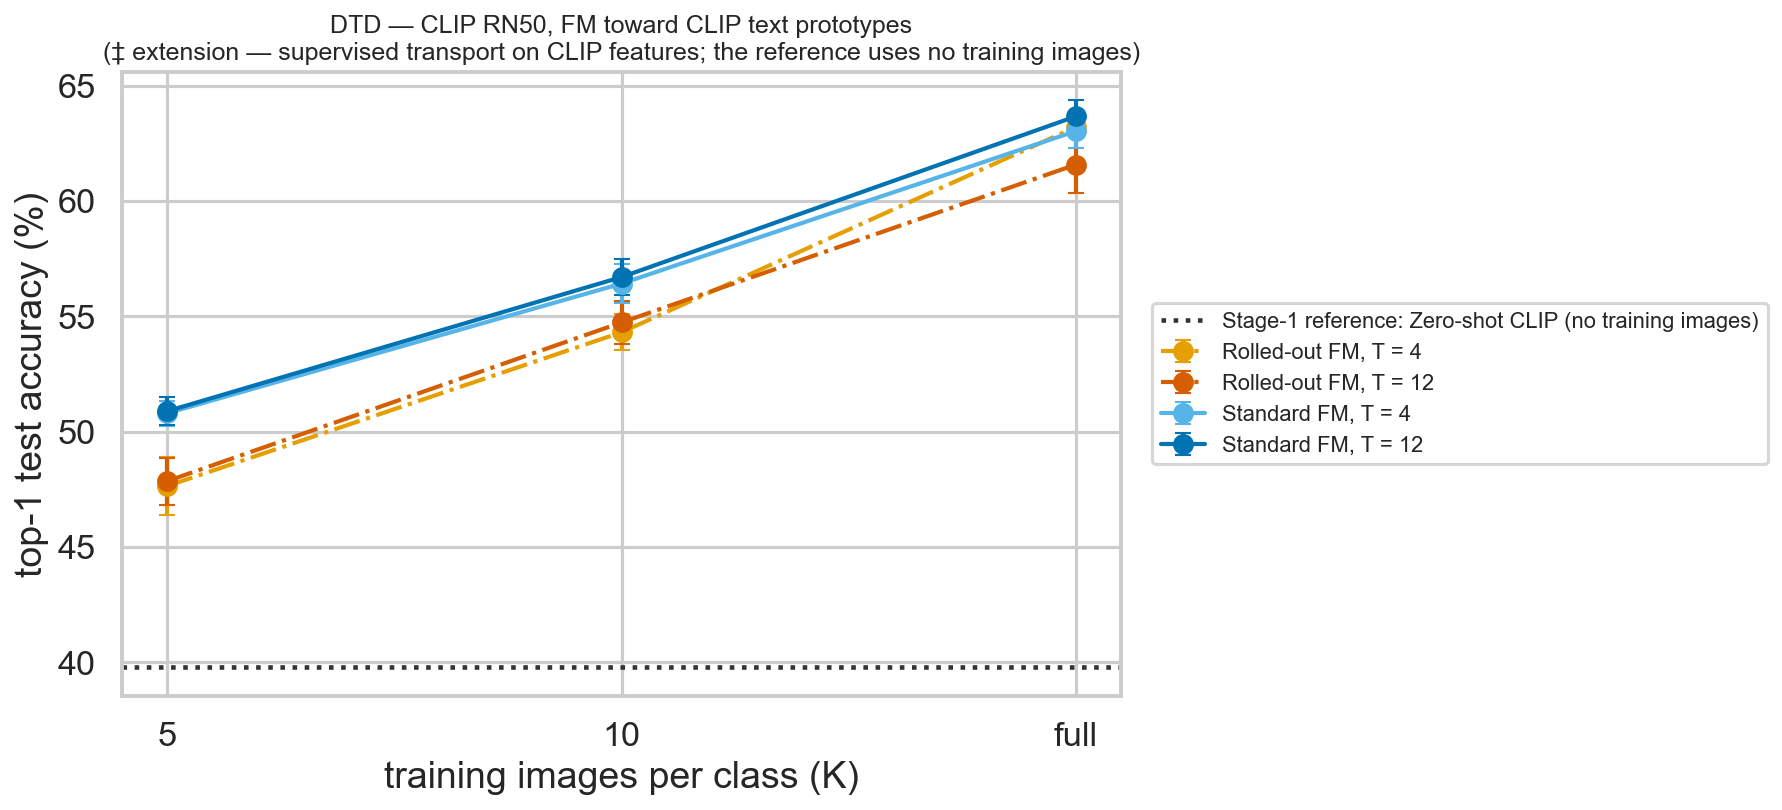

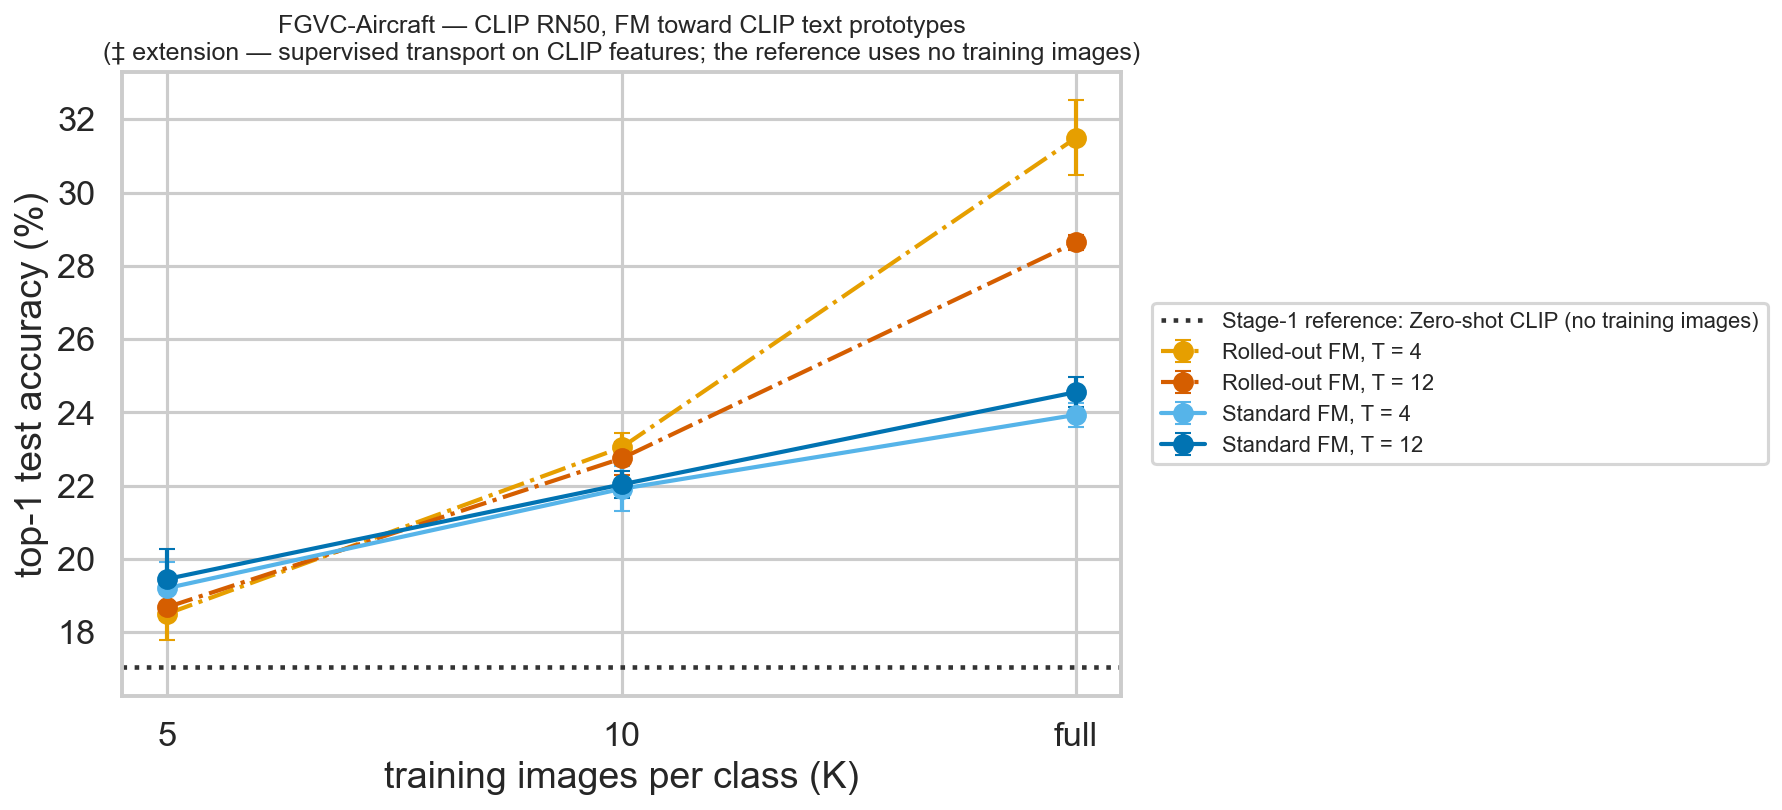

In [8]:
for name in ("stage2_acc_dtd_clip_rn50_clip_text.png",
             "stage2_acc_fgvc_aircraft_clip_rn50_clip_text.png"):
    p = REPO / "results" / "figures" / name
    if p.exists():
        display(Image(str(p), width=880))

### 3.3 Reading the grid — computed, not asserted

The cell below reduces the full grid to the quantities the discussion rests on: per (branch, head, $T$) the number of settings with a positive mean delta, and the extreme deltas.

In [9]:
r2 = pd.read_csv(REPO / "results" / "metrics" / "summary_stage2.csv")
g = (r2.assign(**{"Δ mean (pts)": (100 * r2["delta_mean"]).round(2)})
       .groupby(["target", "head", "T"])
       .agg(**{"settings": ("delta_mean", "size"),
               "Δ > 0": ("delta_mean", lambda d: int((d > 0).sum())),
               "best Δ (pts)": ("delta_mean", lambda d: round(100 * d.max(), 2)),
               "worst Δ (pts)": ("delta_mean", lambda d: round(100 * d.min(), 2)),
               "mean Δ (pts)": ("delta_mean", lambda d: round(100 * d.mean(), 2))}))
display(g)

settings  Δ > 0  best Δ (pts)  worst Δ (pts)  \
target          head        T                                                  
clip_text       fm_rollout  4          6      6         23.42           1.46   
                            12         6      6         21.79           1.64   
                fm_standard 4          6      6         23.24           2.16   
                            12         6      6         23.88           2.41   
image_prototype fm_rollout  4          9      4         20.95         -12.87   
                            12         9      5         19.86         -12.62   
                fm_standard 4          9      7         23.17          -4.68   
                            12         9      7         22.86          -4.10   

                                mean Δ (pts)  
target          head        T                 
clip_text       fm_rollout  4          11.29  
                            12         10.62  
                fm_standard 4          10.80  
                            12         11.13  
image_prototype fm_rollout  4           2.59  
                            12          2.80  
                fm_standard 4           6.09  
                            12          6.15

## 4 · Training curves and stability — and the one contingency that triggered

The spec's stated purpose for these curves is to verify that training is **stable** and that both approaches reach reasonable solutions. Stability is a load-bearing claim here (no validation checkpointing exists to absorb a bad ending), so it is not read off two representative plots: the cell below evaluates the a-priori criterion from ADR 0007 §7 over **every** saved training curve — a run counts as *unstable* if its final-epoch training loss exceeds $1.05\times$ its own running minimum (divergence, not plateau).

**The criterion fired.** On the first (final-epoch) grid, 3 of 135 runs genuinely diverged — all rolled-out models at K = full, the worst at $62\times$ its minimum with test accuracy collapsed to ~6% (recorded at trigger time; the first grid's artifacts were superseded by the re-run) — alongside 20 marginal 1.05–1.13× cases (18 standard-FM runs, where random-$t$ resampling makes the last epoch noisy, and 2 rolled-out runs just past the threshold; this 3-vs-20 split is our post-hoc description — the pre-registered criterion is binary at 1.05× and the uniform fallback applies regardless of it).

**Could min-training-loss pick a "lucky" epoch?** A fair objection: standard FM's per-epoch loss fluctuates with the random-$t$ draws, so the minimum could land on an epoch whose draws happened to be easy. Three answers, all checkable. First, the selection statistic uses training data only, and the test set is evaluated once on the selected checkpoint — no quantity involved in the selection is correlated with test noise, so the selection cannot be optimistic *toward test accuracy* (it is a winner's curse on the training loss, adding variance, not test bias). Second, the cell below prints where the selected epochs actually land: essentially at the end of training (medians ≈ 193–197 of 200) for every stable run — the rule effectively returns the late-training model everywhere except the divergences it exists to catch. Third, the superseded final-epoch grid's stable-run accuracies differed from the published ones only by tenths of a point in both directions (the first grid's DTD arrays are preserved at commit `cbceb53` and were compared during the adversarial review). As pre-registered, the uniform fallback was applied: **every model, both modes and both branches, was re-trained/selected at its minimum-training-loss epoch**, and the whole grid re-run. The first grid's numbers were never published. All numbers in this notebook come from the fallback grid; the cell below documents the divergence pattern that triggered it (final vs minimum loss on the *saved* curves — the checkpoint used is always the minimum).

Note the two objectives live on different scales (standard FM regresses velocities along the whole path; rolled-out FM penalizes only the final-state distance), hence the log axis; curve *shapes*, not absolute levels, are the comparable quantity.

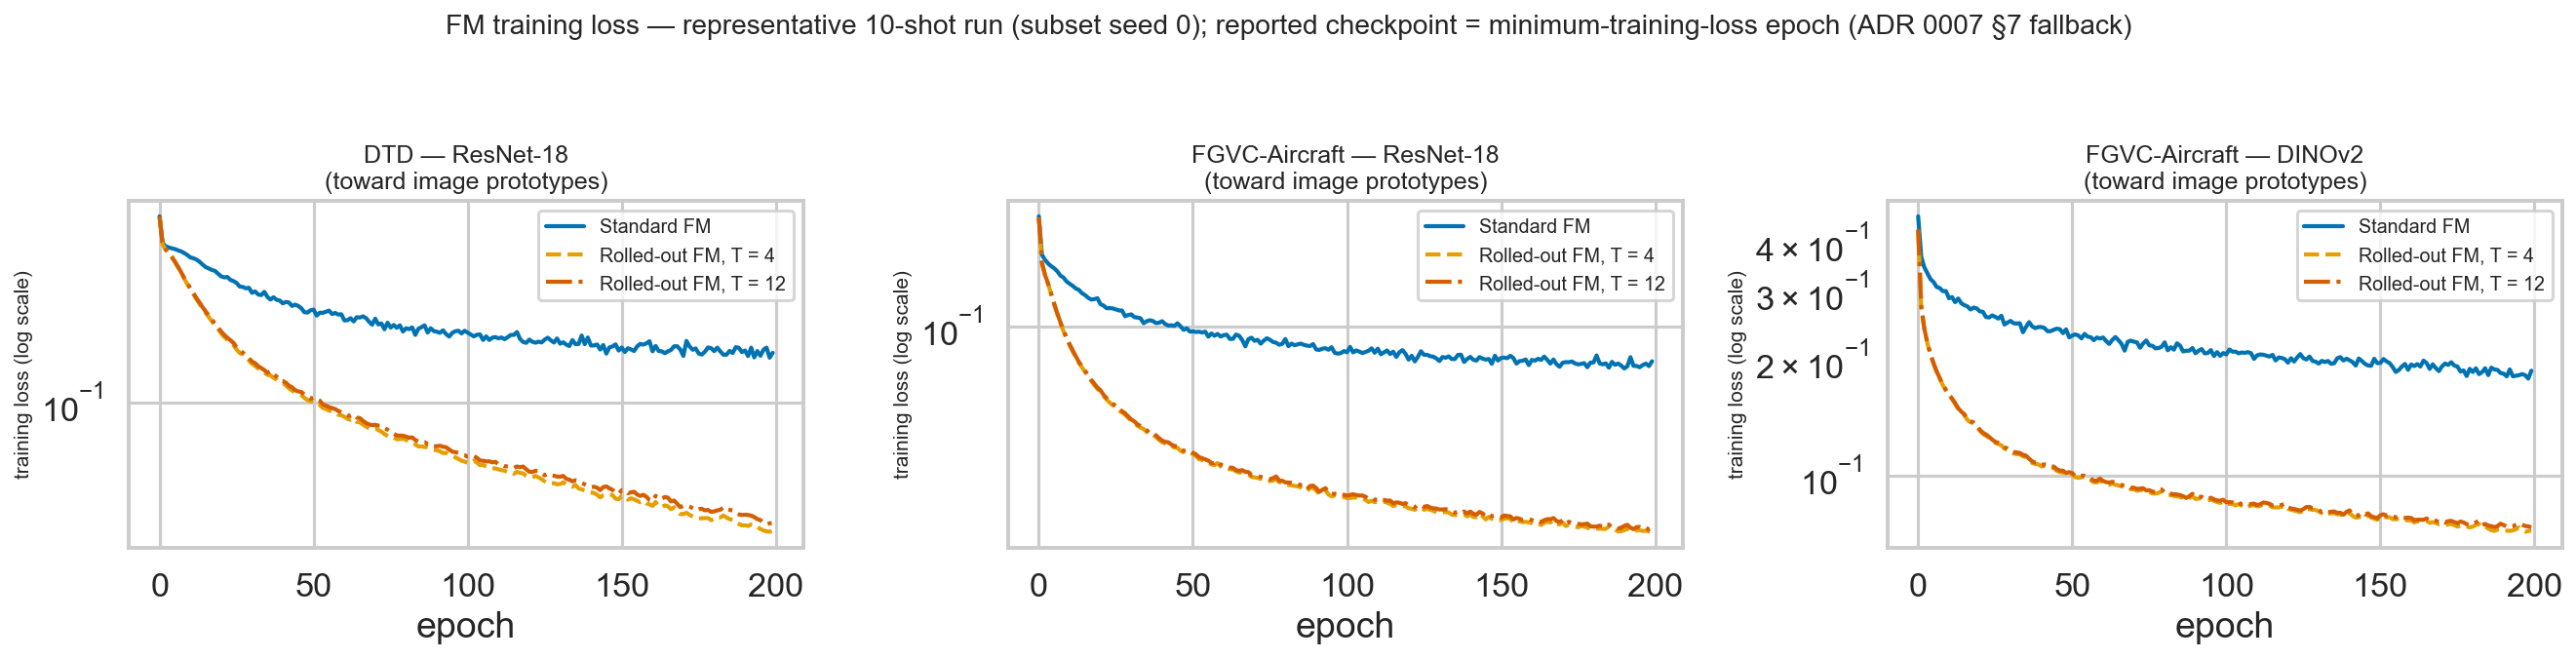

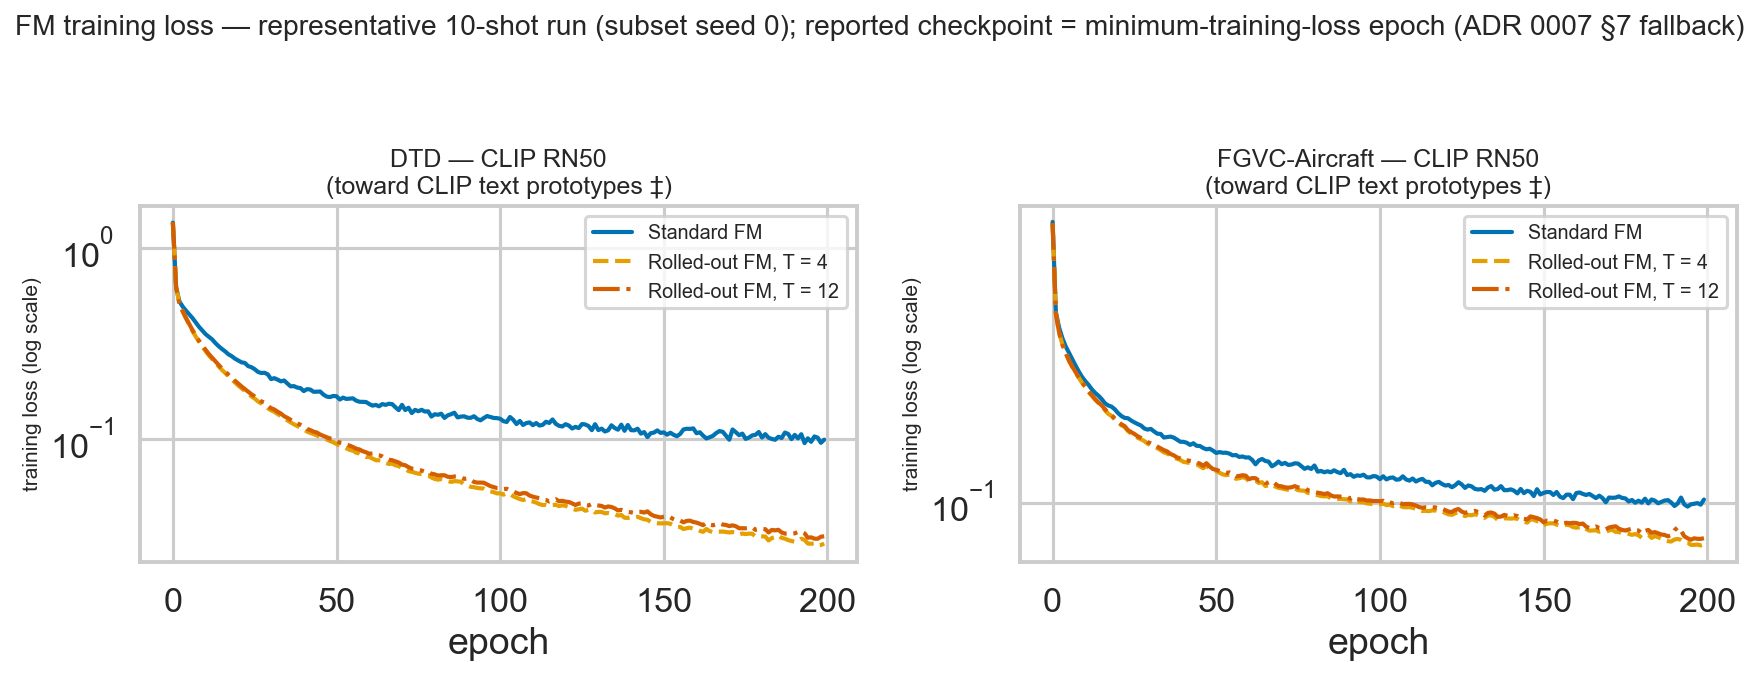

In [10]:
for name in ("stage2_curves_0.png", "stage2_curves_1.png"):
    p = REPO / "results" / "figures" / name
    if p.exists():
        display(Image(str(p), width=980))

In [11]:
import json as _json

curve_dir = REPO / "results" / "artifacts" / "curves_stage2"
curves = [p for p in sorted(curve_dir.glob("*.json"))
          if "_smoke" not in p.name and "_raw" not in p.name]
rows = []
for p in curves:
    with open(p) as f:
        h = _json.load(f)["train_loss"]
    ratio = h[-1] / min(h)
    if ratio > 1.05:
        rows.append({"curve": p.name, "final / min loss": round(ratio, 2)})
rows.sort(key=lambda r: -r["final / min loss"])
print(f"Stability criterion (ADR 0007 §7) over all {len(curves)} curves: "
      f"{len(rows)} exceed 1.05x (checkpoint used = min-loss epoch, so divergent "
      f"endings do not enter any reported number)")
display(pd.DataFrame(rows[:10]))

# Where do the selected (min-training-loss) checkpoints actually land?
r2 = pd.read_csv(REPO / "results" / "metrics" / "runs_stage2.csv")
ck = (r2.drop_duplicates(subset=["dataset", "encoder", "target", "head",
                                 "k_shot", "seed", "T"])
        .groupby("head")["checkpoint_epoch"].agg(["min", "median", "max"]))
print("\nSelected checkpoint epoch (of 200) by training mode:")
display(ck)
print("=> the min-loss rule effectively selects the late-training model "
      "everywhere except the diverged runs it exists to catch.")

Stability criterion (ADR 0007 §7) over all 135 curves: 23 exceed 1.05x (checkpoint used = min-loss epoch, so divergent endings do not enter any reported number)


,curve,final / min loss
0,fgvc_aircraft_clip_rn50_clip_text_fm_rollout_T...,62.43
1,fgvc_aircraft_resnet18_image_prototype_fm_roll...,2.93
2,fgvc_aircraft_resnet18_image_prototype_fm_roll...,1.26
3,dtd_clip_rn50_clip_text_fm_standard_5shot_seed...,1.13
4,dtd_clip_rn50_clip_text_fm_standard_5shot_seed...,1.13
5,dtd_resnet18_image_prototype_fm_standard_5shot...,1.12
6,dtd_resnet18_image_prototype_fm_standard_5shot...,1.11
7,fgvc_aircraft_dinov2_vits14_image_prototype_fm...,1.09
8,fgvc_aircraft_resnet18_image_prototype_fm_stan...,1.09
9,dtd_clip_rn50_clip_text_fm_standard_5shot_seed...,1.08



Selected checkpoint epoch (of 200) by training mode:


,min,median,max
head,,,
fm_rollout,88,197.0,199
fm_standard,159,193.0,199


=> the min-loss rule effectively selects the late-training model everywhere except the diverged runs it exists to catch.


## 5 · How the learned transformation changes the feature-space geometry

**Feature-space comparison** (spec item 3). For each setting: the same ten classes, test examples, and class colours as the Stage-1 visualizations; three views — original features, after standard FM, after rolled-out FM — plus the prototypes the models were actually trained toward (the 10-shot seed-0 prototypes, not the full-split ones). **One PCA is fitted jointly to all three feature sets and the prototypes**, so the three panels share a single plane and positions are directly comparable across panels (spec requirement). Representative models: $K = 10$, subset seed 0, $T = 12$, fixed a priori. As in Stage 1, 2-D projections are qualitative.

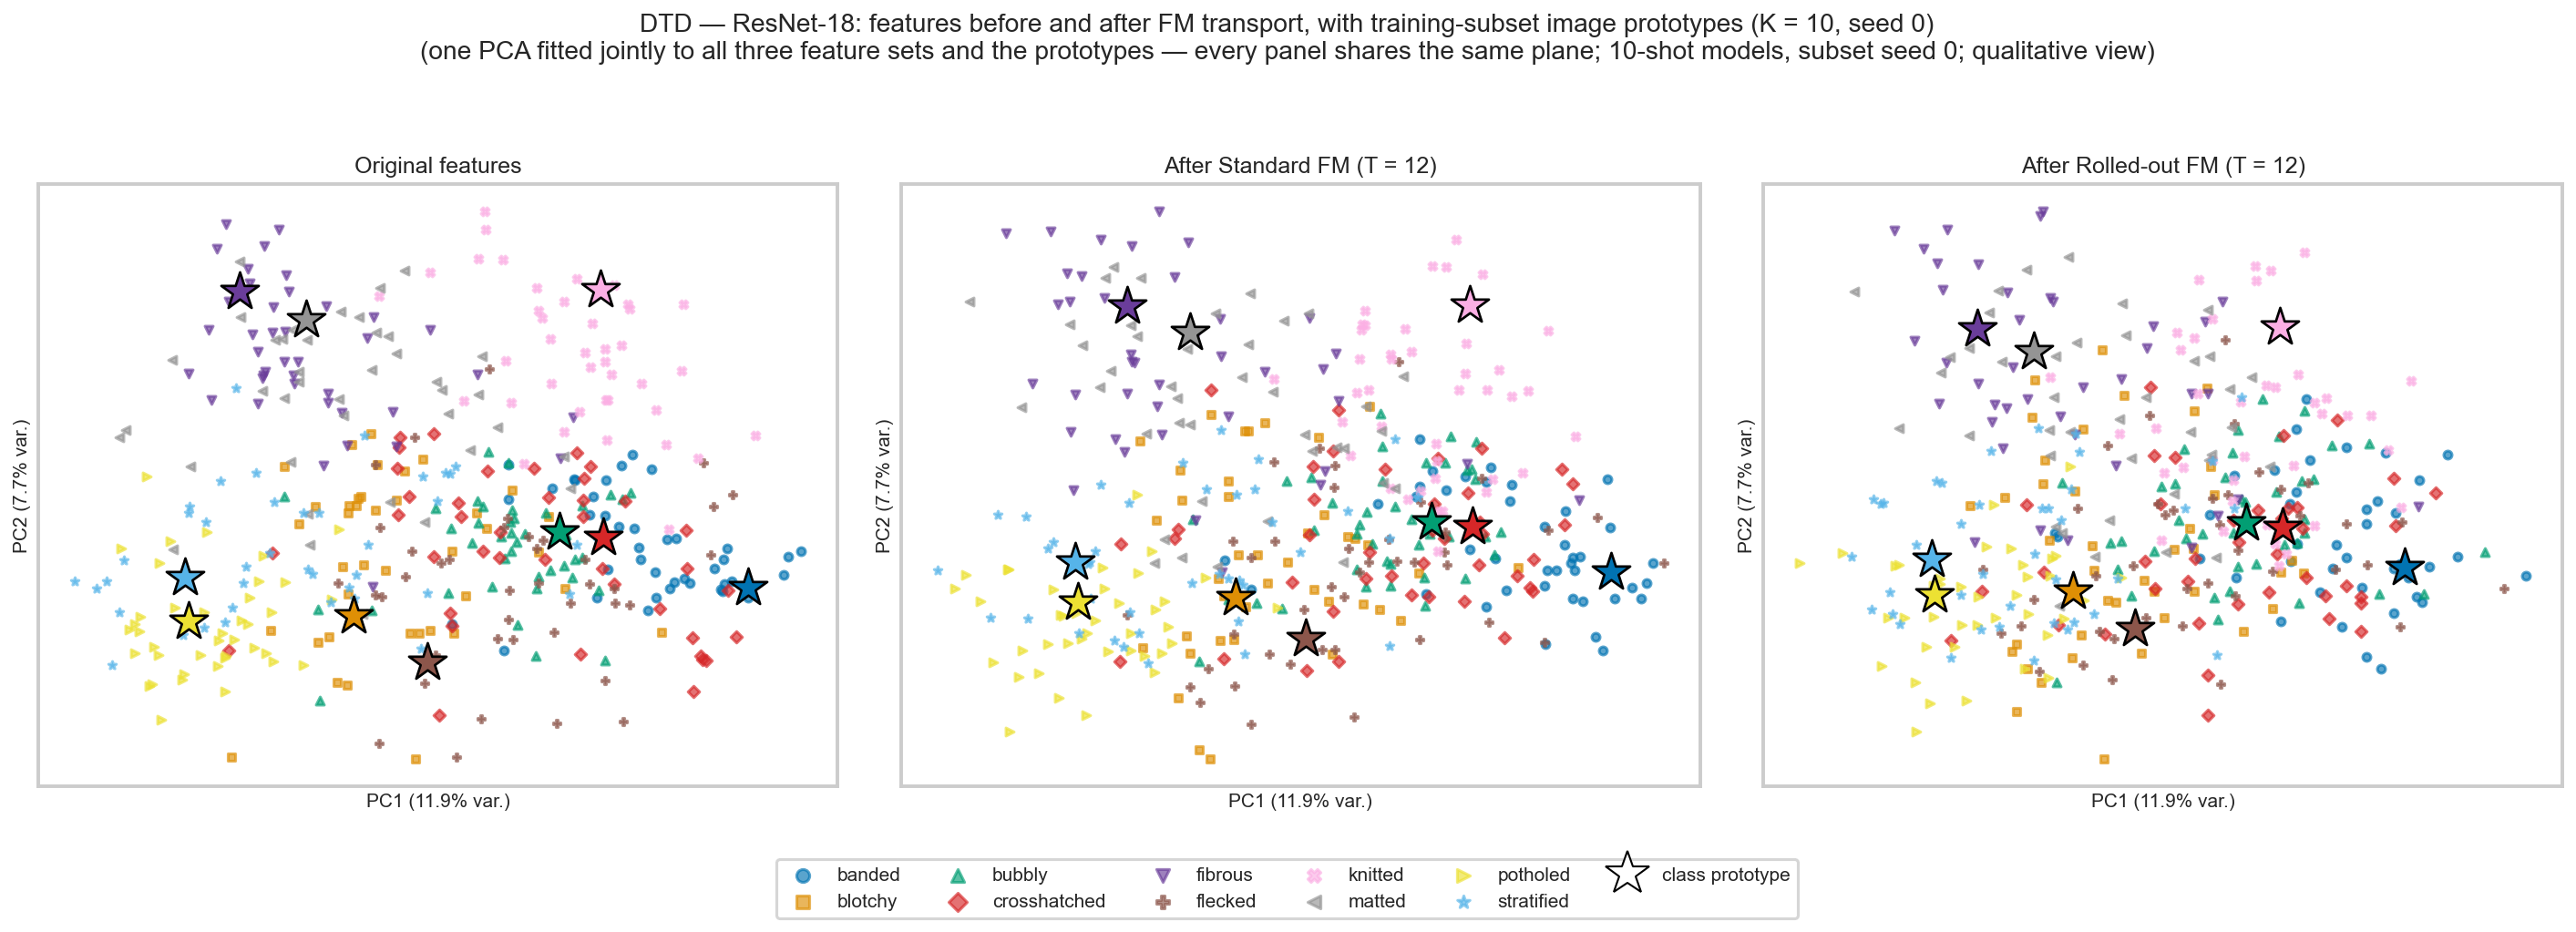

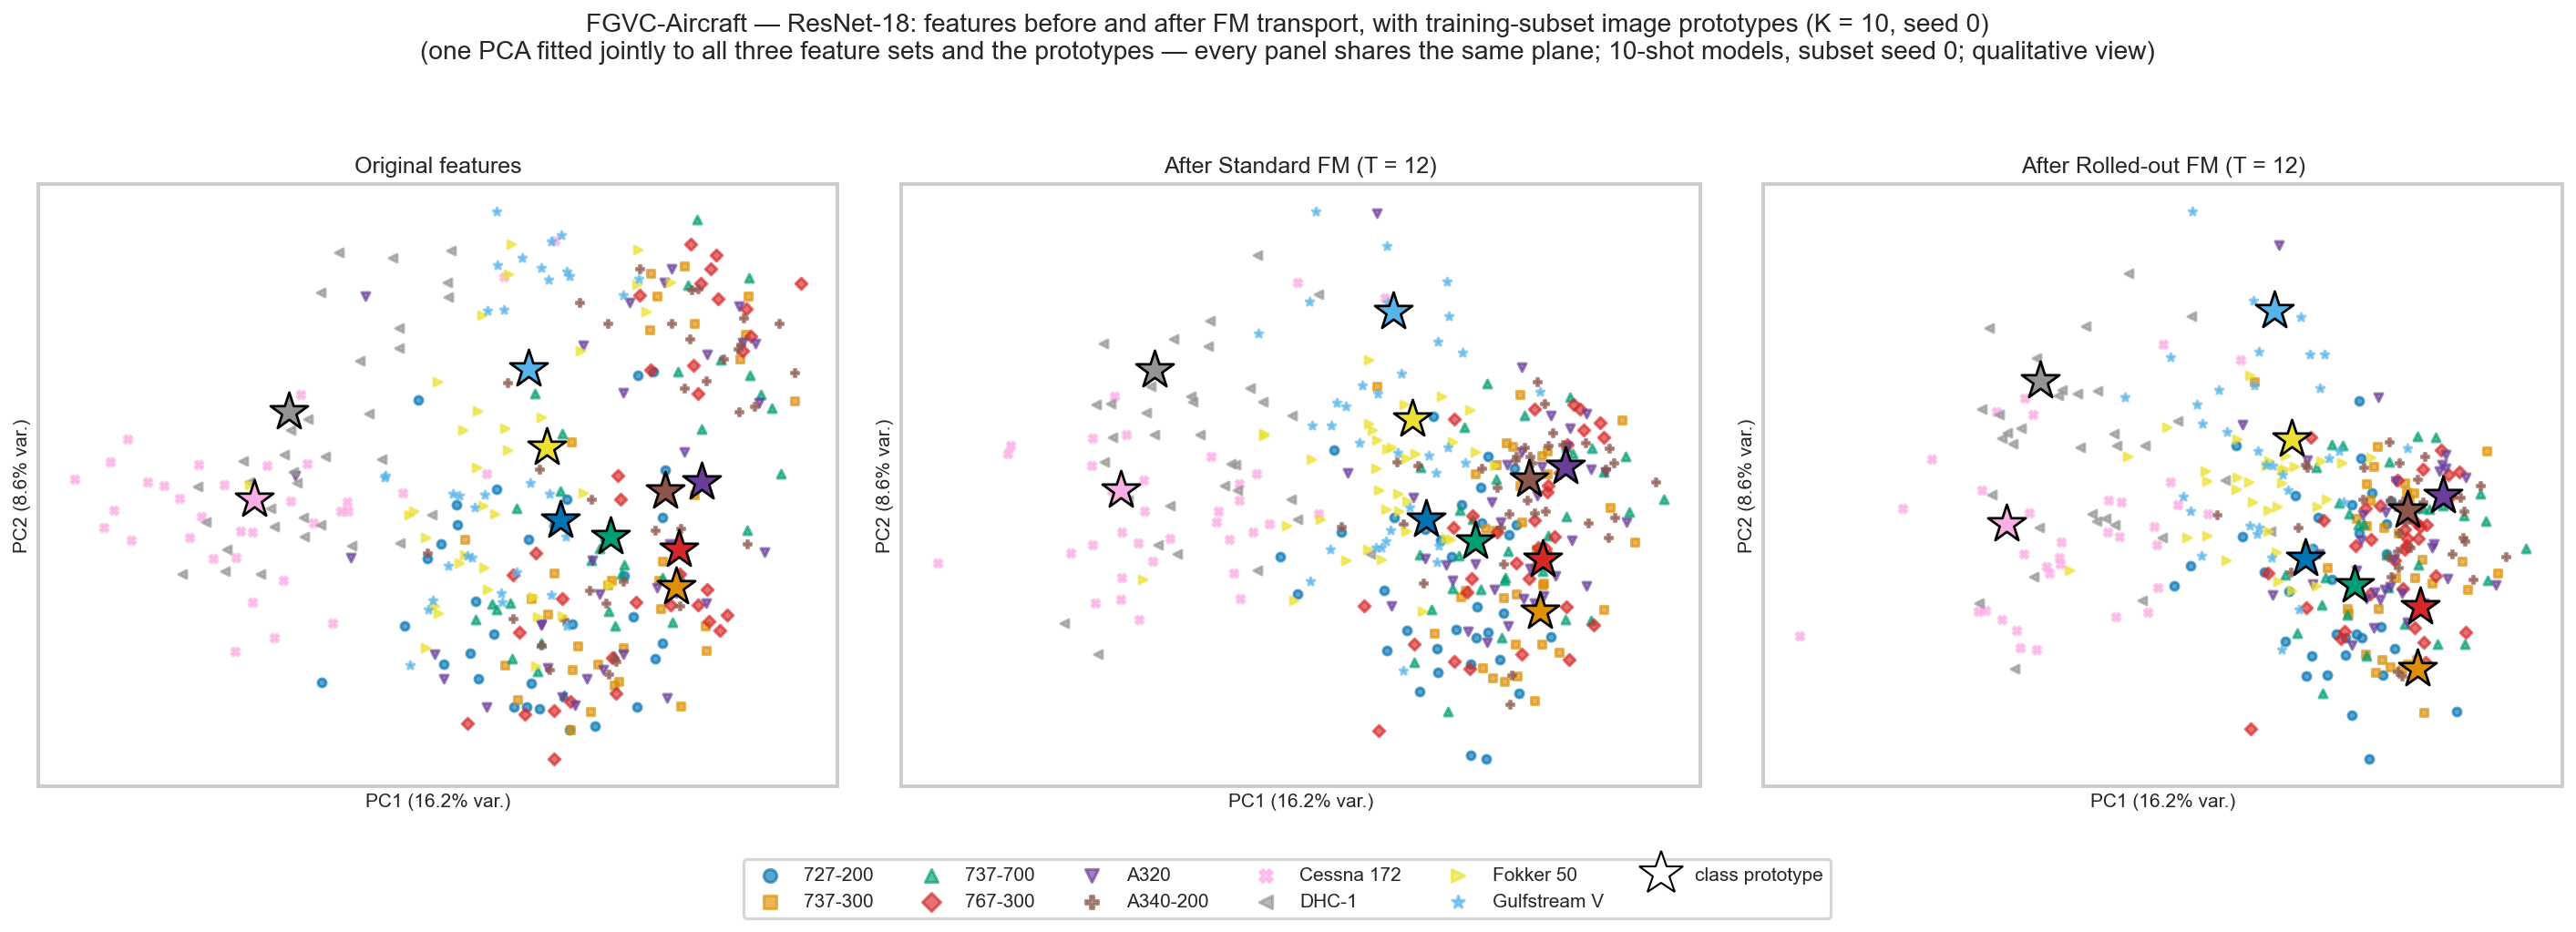

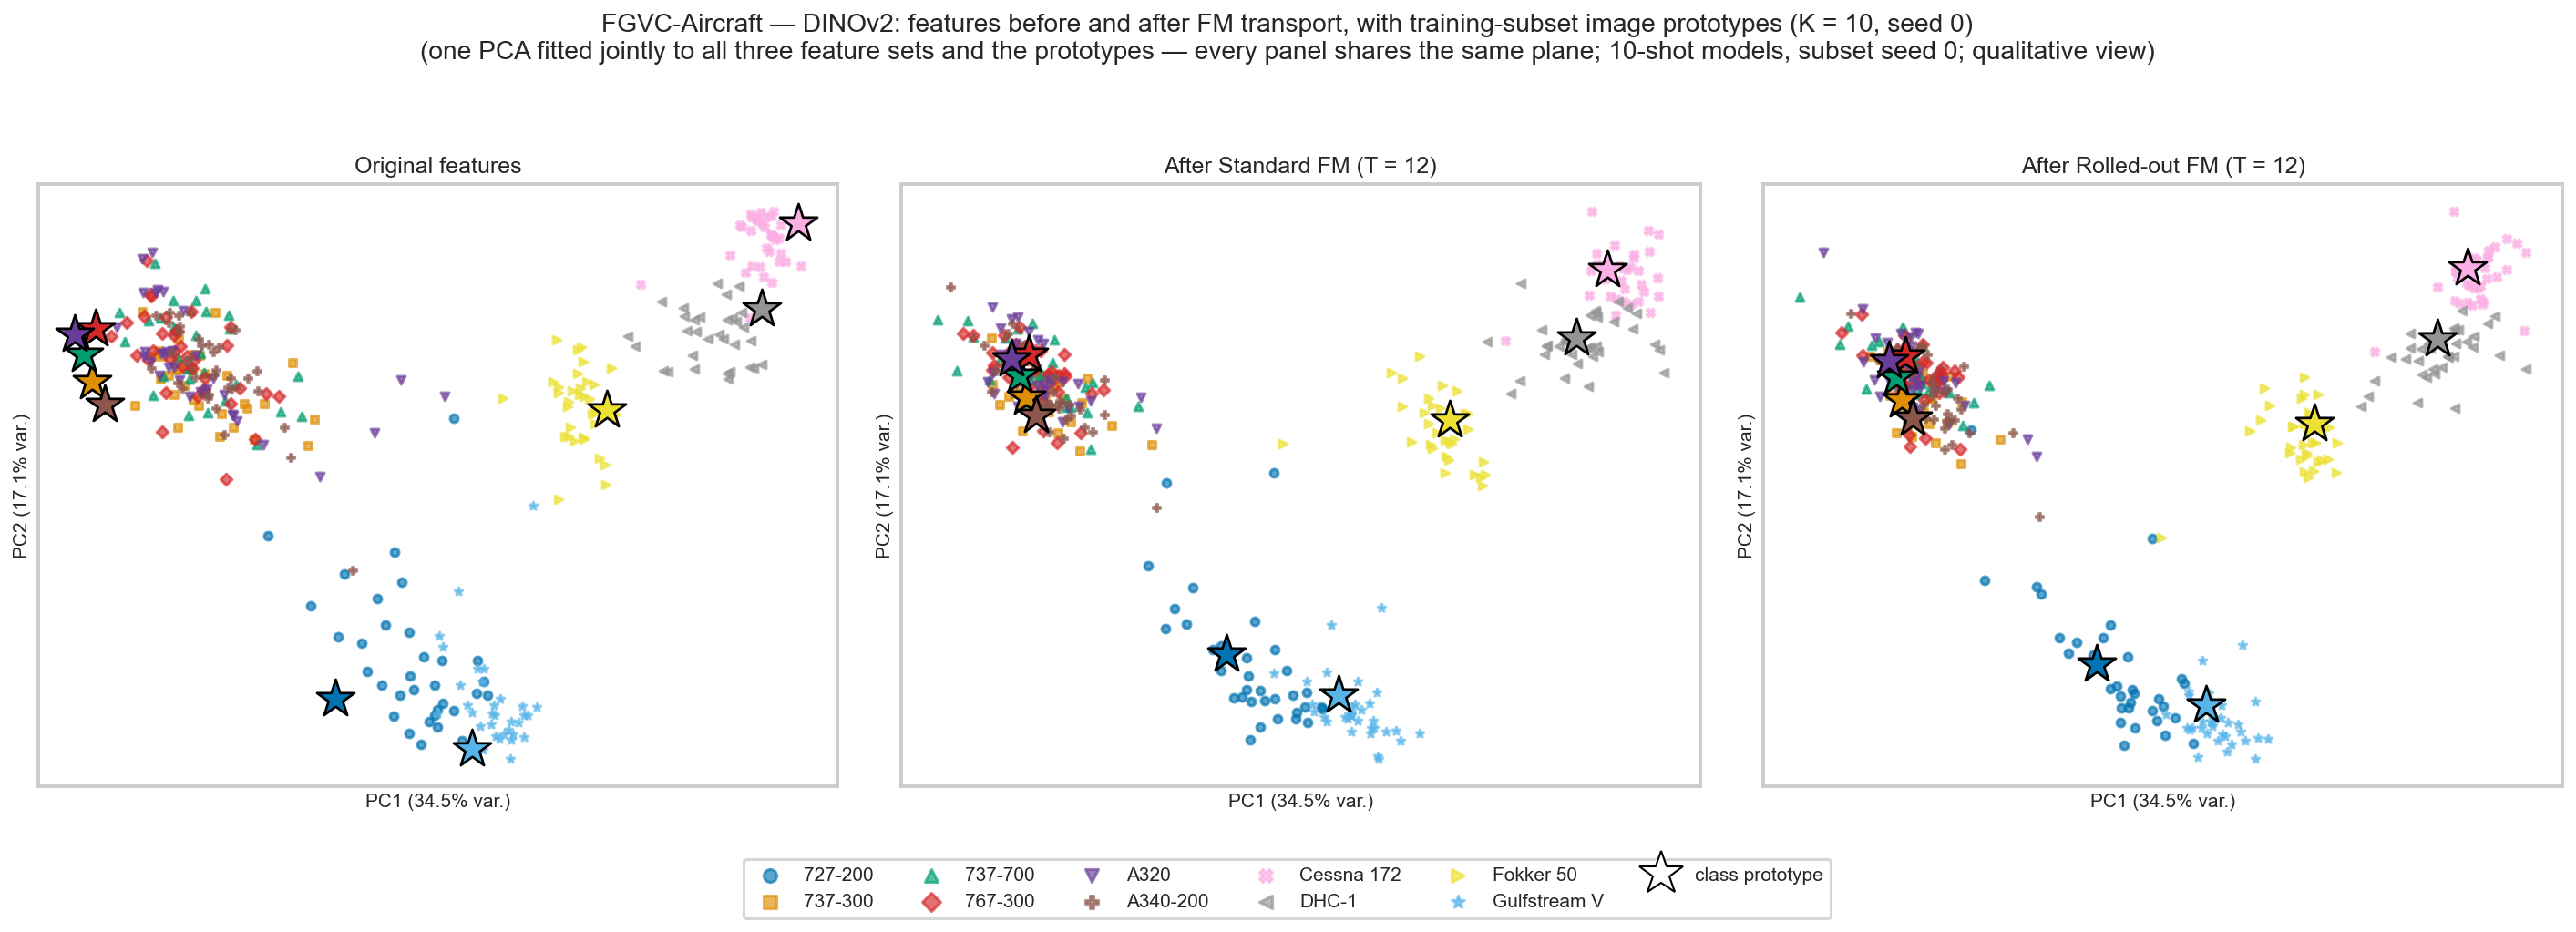

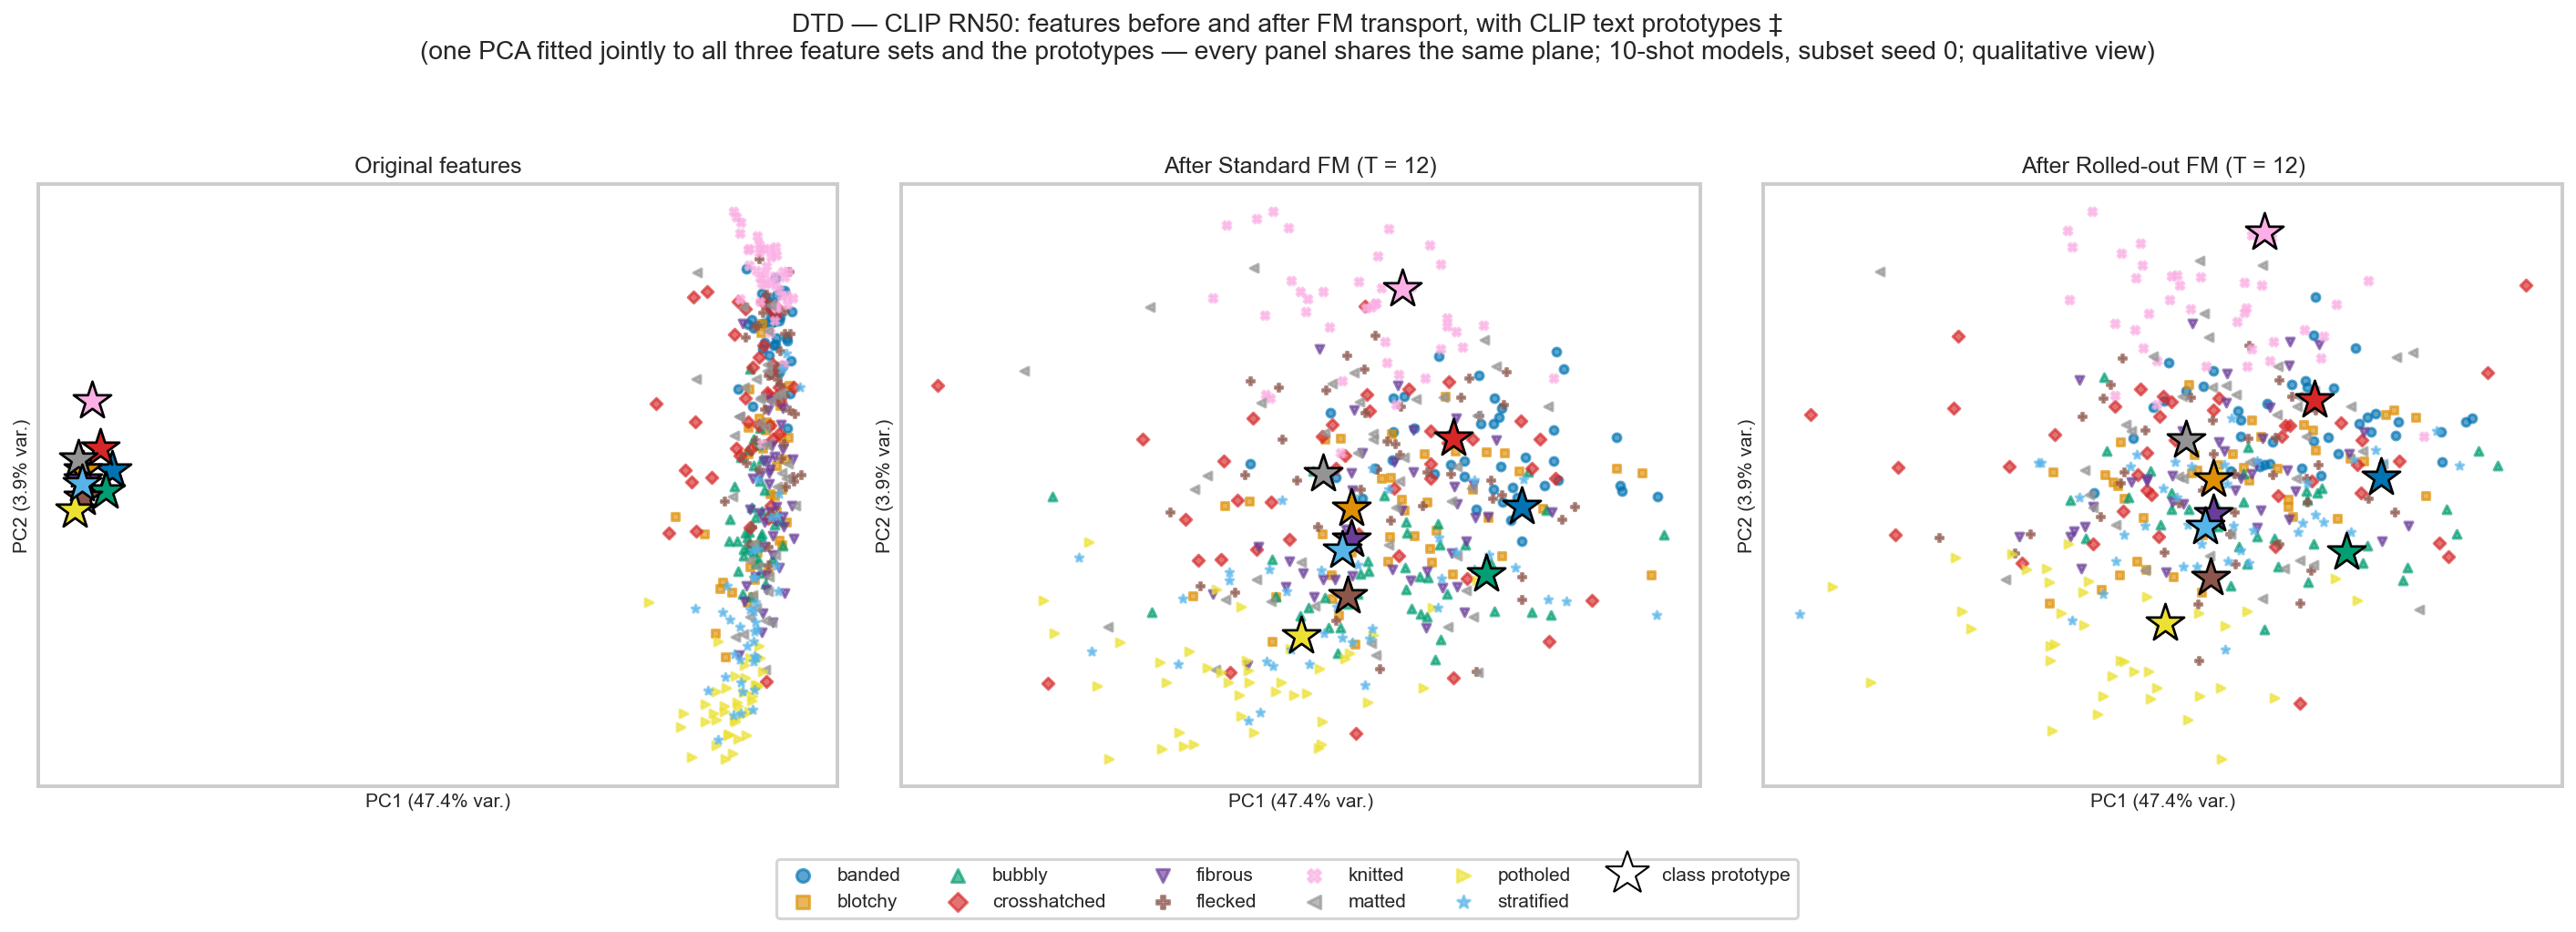

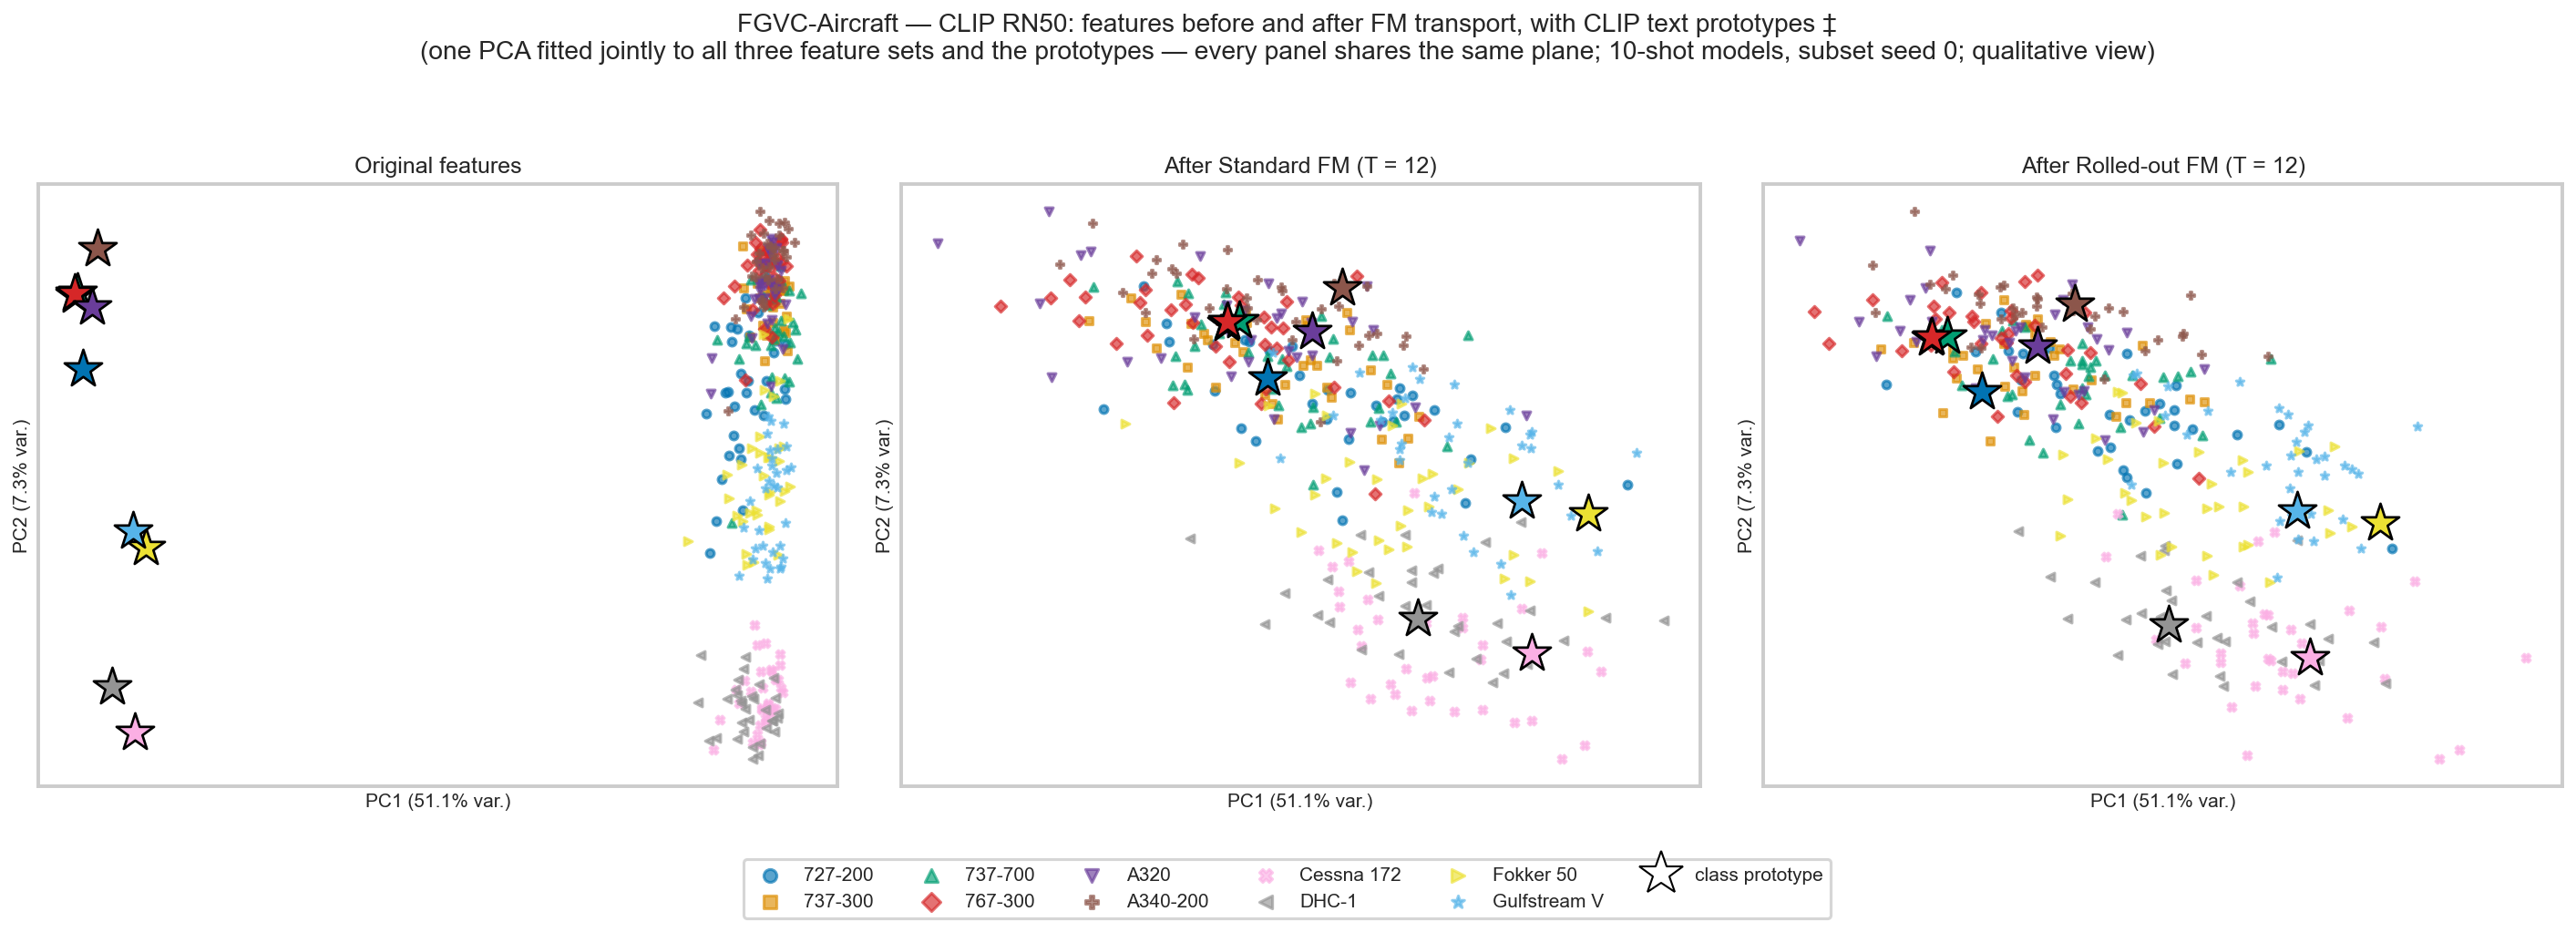

In [12]:
for name in ("stage2_features_dtd_resnet18_image_prototype.png",
             "stage2_features_fgvc_aircraft_resnet18_image_prototype.png",
             "stage2_features_fgvc_aircraft_dinov2_vits14_image_prototype.png",
             "stage2_features_dtd_clip_rn50_clip_text.png",
             "stage2_features_fgvc_aircraft_clip_rn50_clip_text.png"):
    p = REPO / "results" / "figures" / name
    if p.exists():
        display(Image(str(p), width=980))

**Flow trajectories** (spec item 4). A small number of representative test examples per setting, with every intermediate Euler state $\hat{z}_0 \to \hat{z}_1 \to \dots \to \hat{z}_T$ drawn in the **same joint PCA plane** as the feature-comparison figure (background: original test features; stars: prototypes; ○ start, ✕ end). PCA is used because projected straight-line segments remain straight-line segments, so the trajectory geometry is interpretable — a t-SNE embedding would not preserve that.

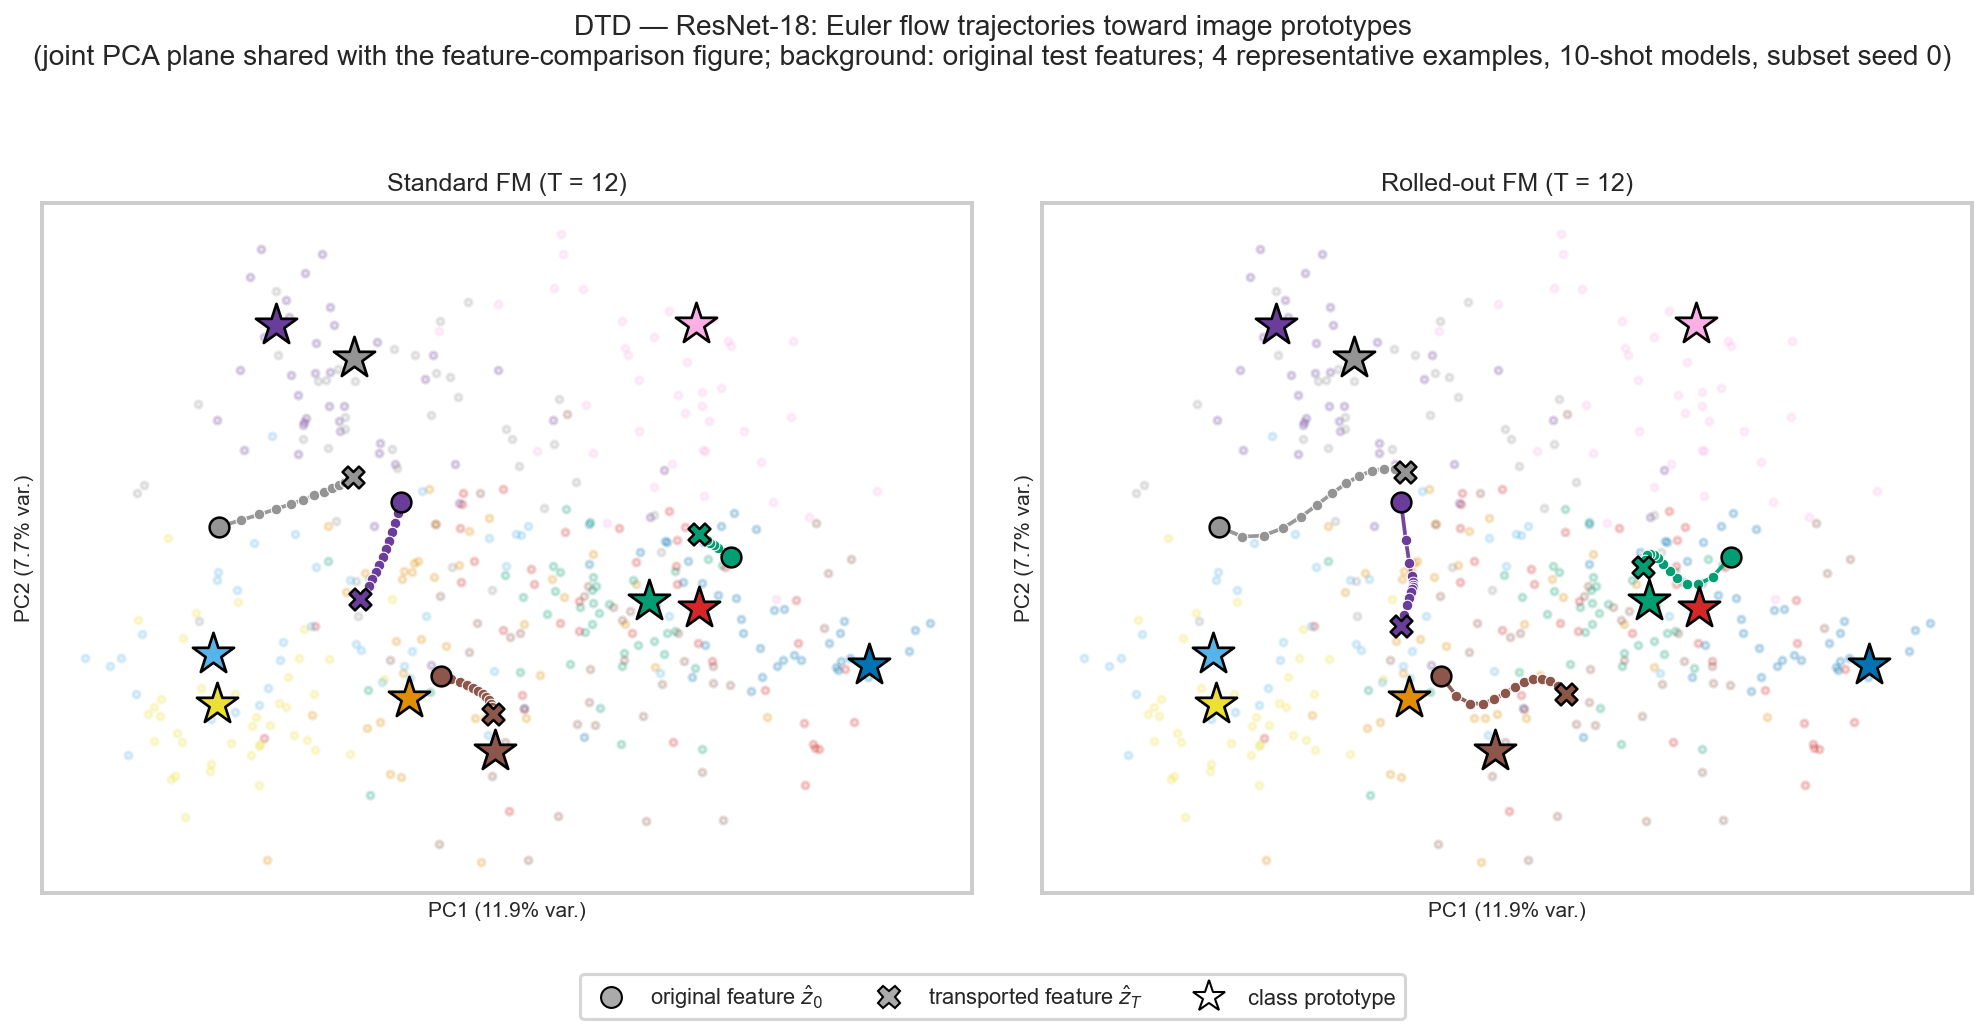

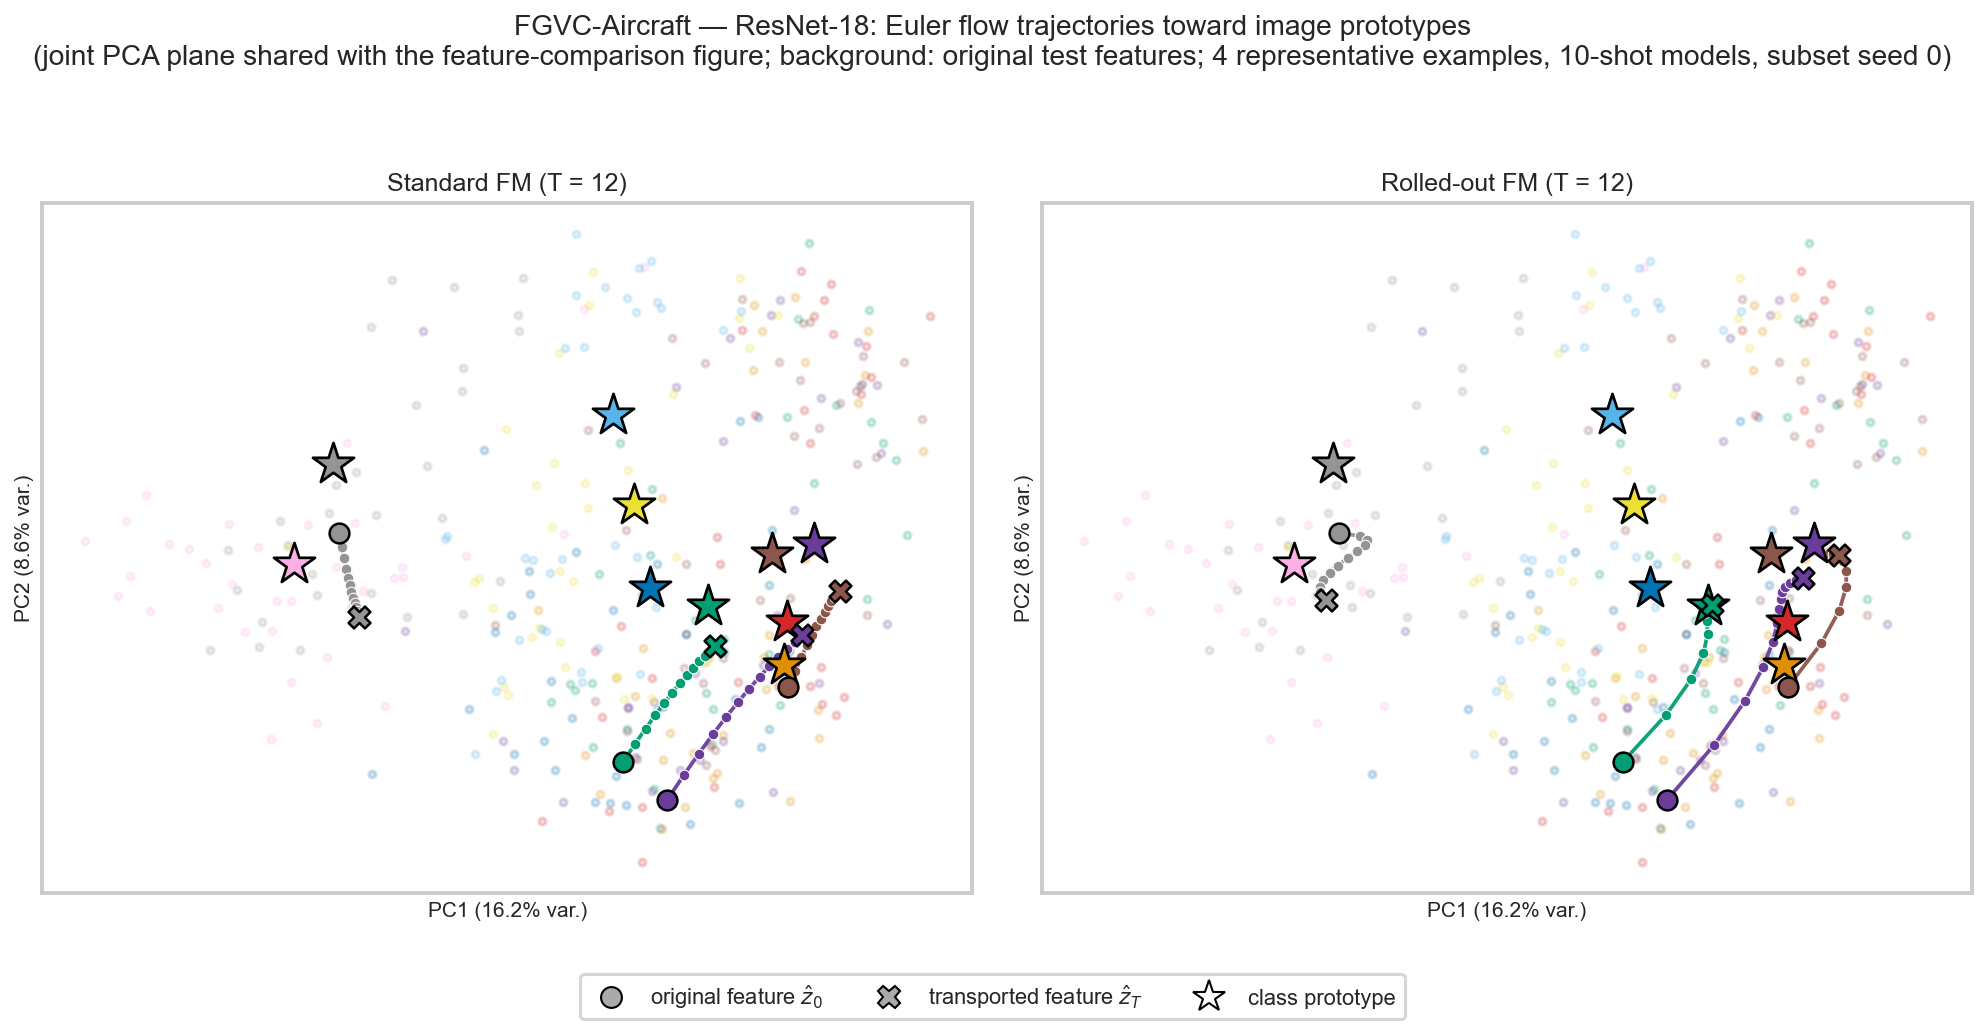

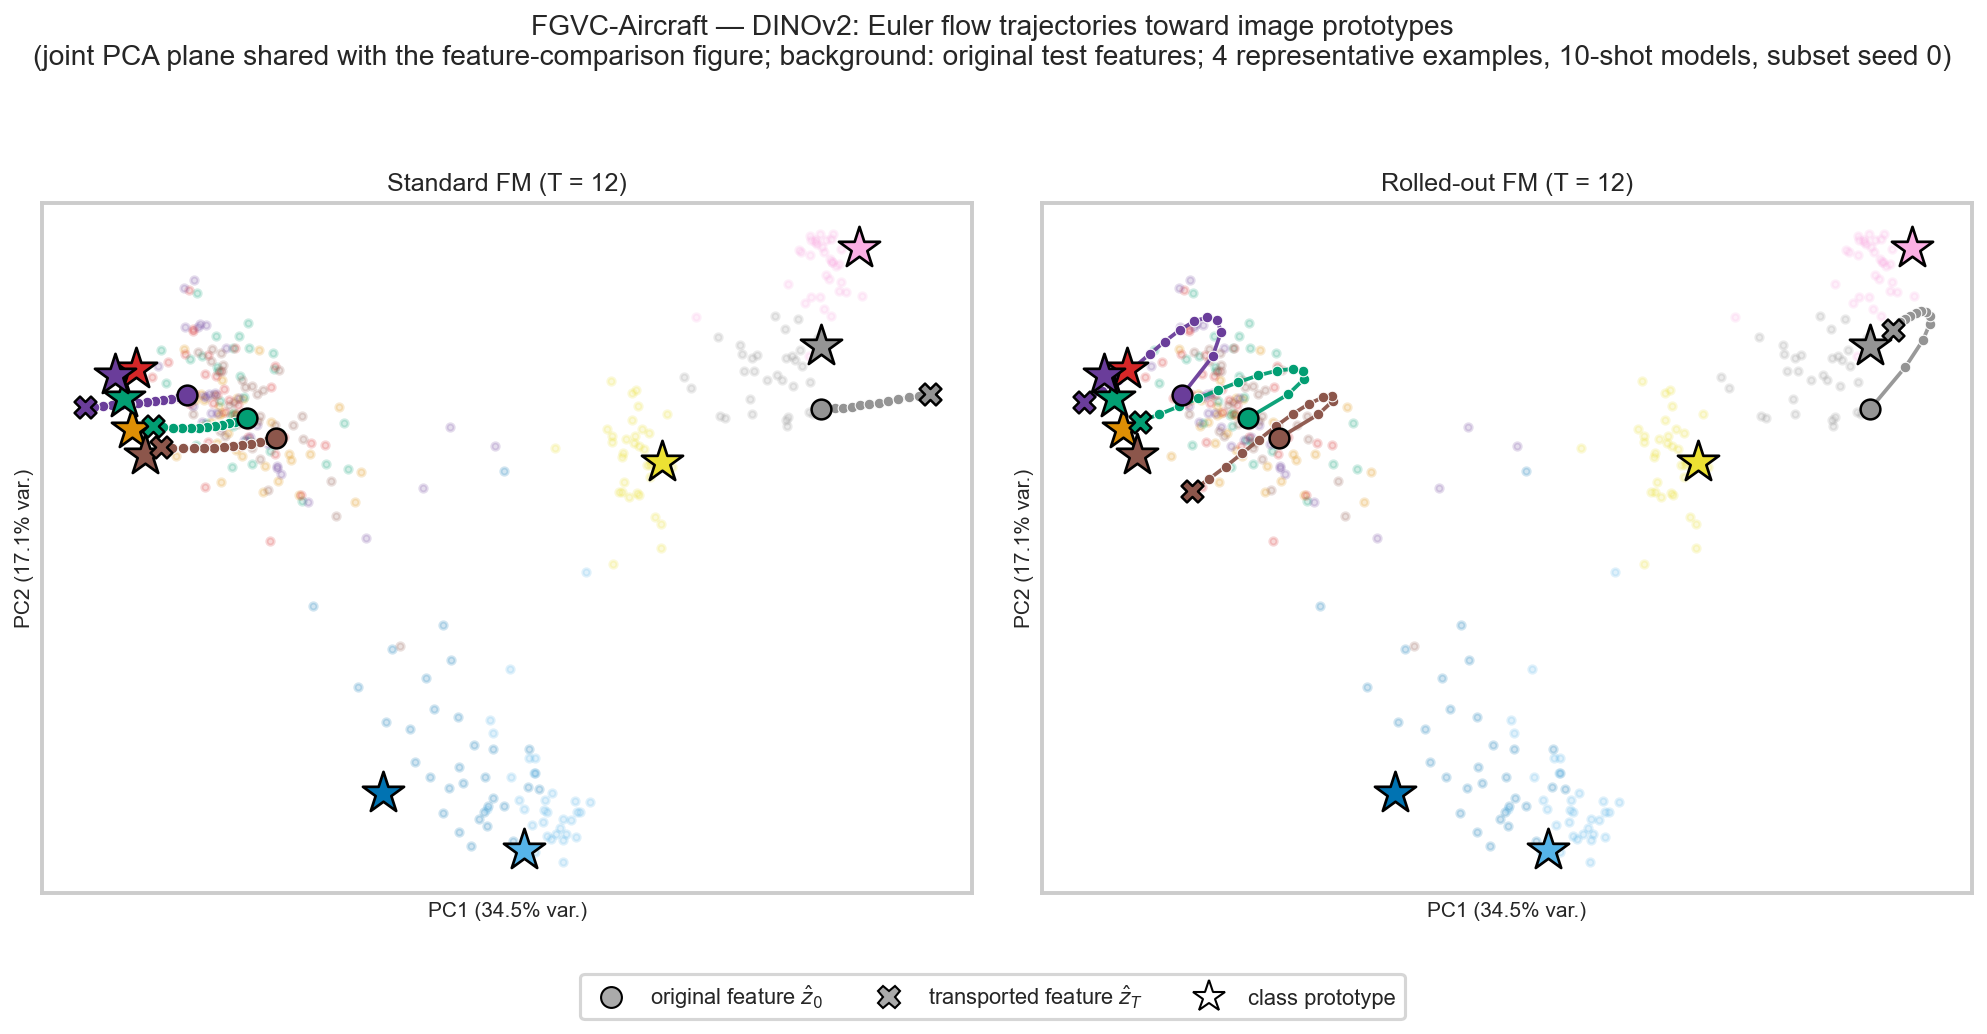

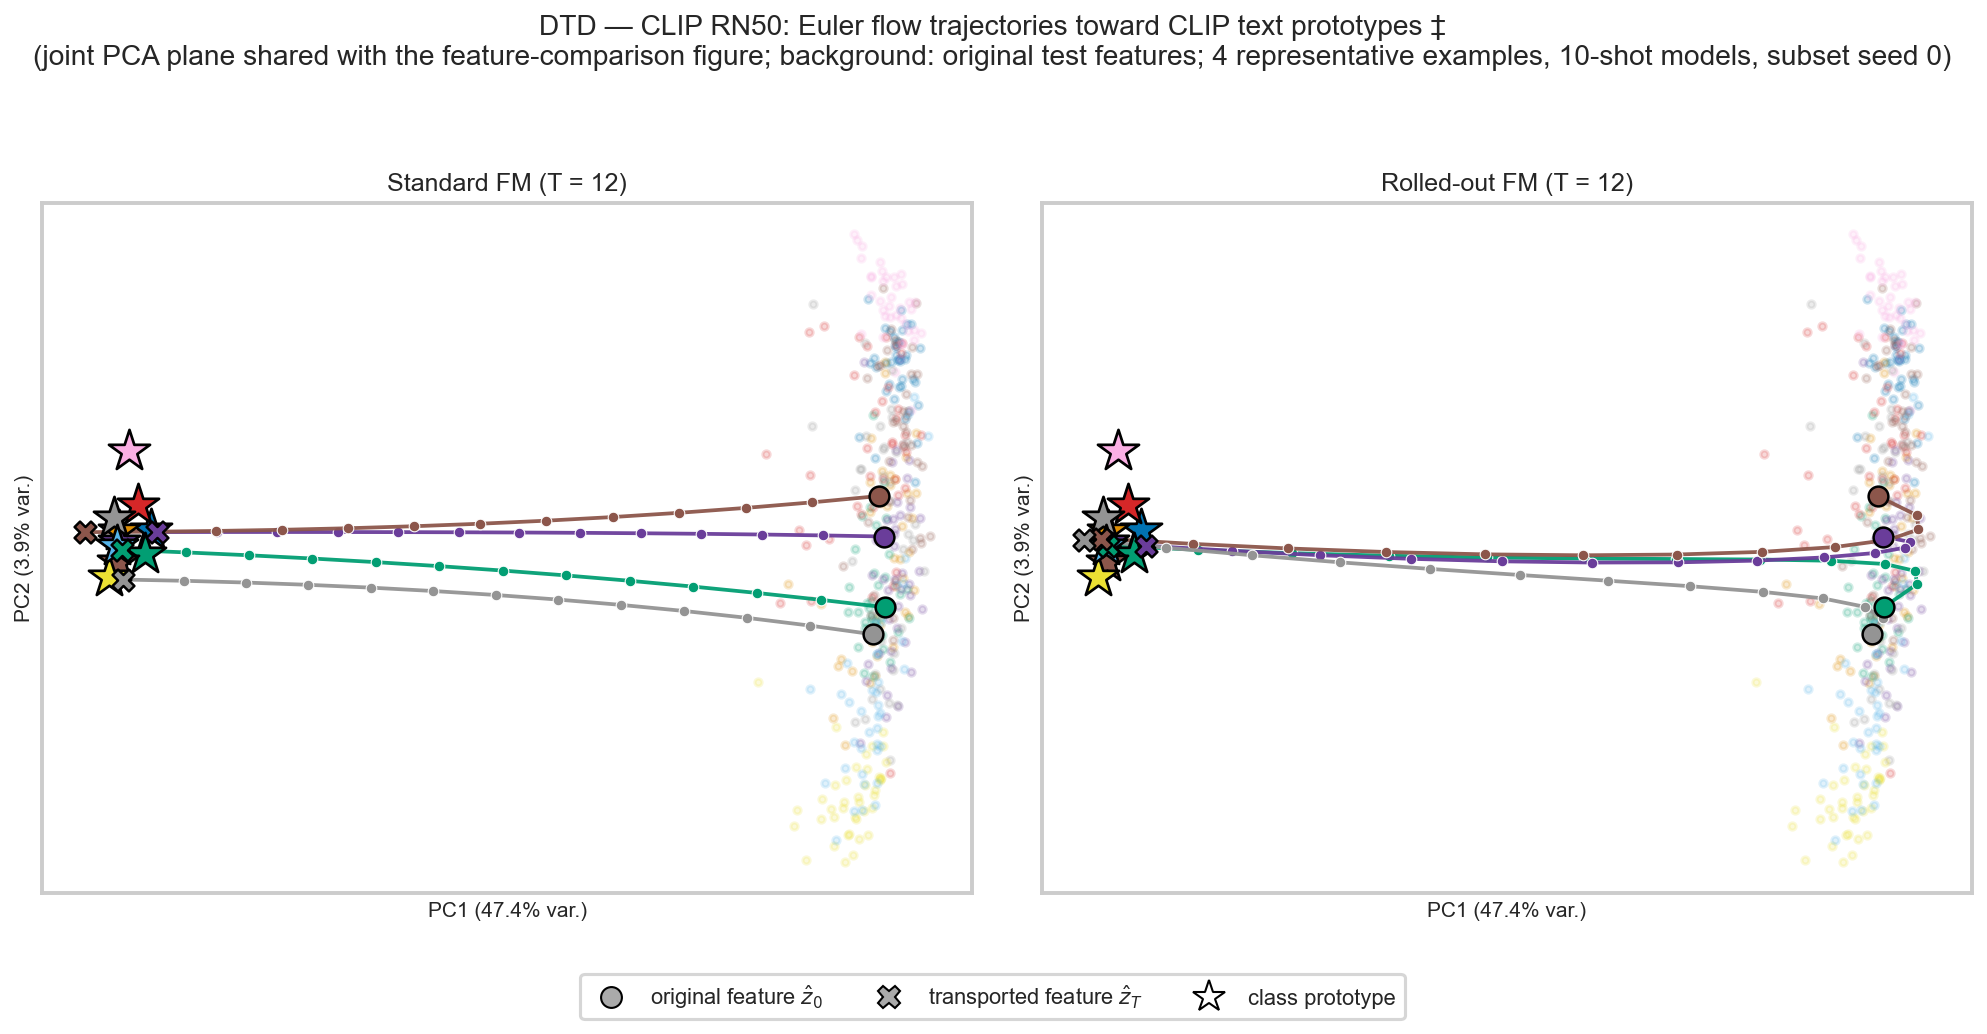

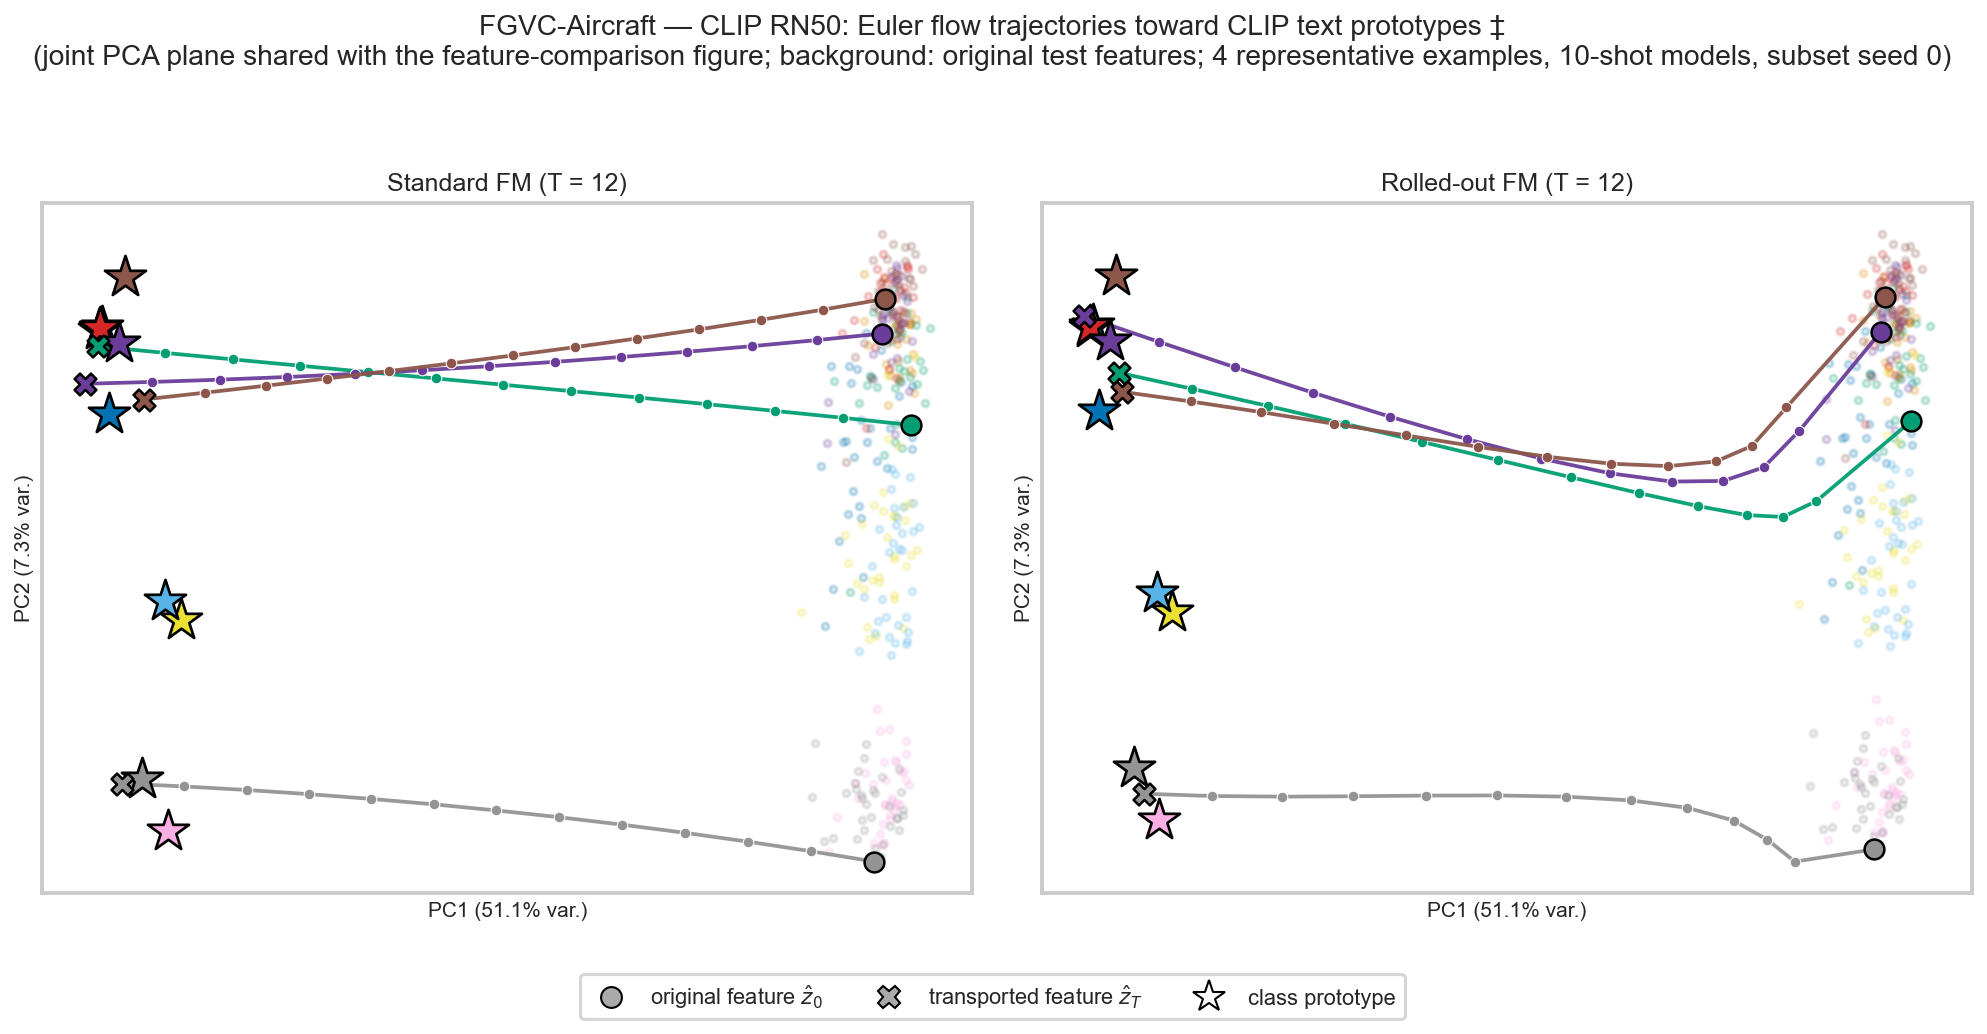

In [13]:
for name in ("stage2_traj_dtd_resnet18_image_prototype.png",
             "stage2_traj_fgvc_aircraft_resnet18_image_prototype.png",
             "stage2_traj_fgvc_aircraft_dinov2_vits14_image_prototype.png",
             "stage2_traj_dtd_clip_rn50_clip_text.png",
             "stage2_traj_fgvc_aircraft_clip_rn50_clip_text.png"):
    p = REPO / "results" / "figures" / name
    if p.exists():
        display(Image(str(p), width=980))

**What the geometry says.** Two structural facts help read these figures:

1. **The trained flow is a contraction toward class regions, not a permutation-free identity.** Both objectives reward moving every training feature of class $c$ onto the single point $p_c$; a perfectly successful transport would collapse each class to one point. On *test* features the collapse is partial: features near a class's training region are pulled to its prototype, features in ambiguous regions are pulled toward whichever prototype's basin they fall in — which is exactly why transport can *create* errors as well as fix them, and why $\Delta$Acc can be negative even when training loss is low. The classification rule only changes where basin boundaries differ from cosine-to-prototype boundaries.

2. **Near $t \to 1$, standard FM learns a conditional average.** With deterministic $(z_i, p_{y_i})$ pairing, all class-$c$ paths converge on $p_c$ as $t \to 1$ while their target velocities $p_c - z_i$ still differ — so at nearly identical inputs the network receives conflicting targets and can only learn their conditional mean. Rolled-out training does not have this consistency problem (it is judged only on where the composed map lands), which is the main mechanism by which the two modes can genuinely differ in late-time geometry — visible in the trajectory figures as the difference between smoothly converging paths and paths that still drift near the prototypes.

### Animated flow trajectories — one example at a time, zoomed

The static trajectory figures above show start, end, and intermediate Euler states at once; the animations below play the **same real transport** through time for the representative setting with the clearest Stage-2 improvement: **FGVC-Aircraft / DINOv2, image prototypes, K = 10, subset seed 0, T = 12**, Standard FM vs Rolled-out FM side by side. (This is deliberately the success case; the failure mode — DTD, where the same transport *loses* accuracy by merging entangled texture classes — is visible in the static DTD trajectory figure above and discussed in §6.) Each of the four representative examples gets its **own animation, zoomed to its trajectory**, and at every iteration an **arrow shows the direction of the current Euler step** — the learned velocity $\tfrac{1}{T}v_\theta(\hat{z}_k, k/T)$, projected into the plot plane.

Everything is loaded from the saved Stage-2 artifacts — the trained velocity networks, the cached test features, and the training prototypes of this exact setting. The four examples, class colours, and the jointly-fitted PCA plane are **identical to the static trajectory figure by construction** (the same helper functions produce them), and the cell verifies programmatically that: each trajectory has exactly $T{+}1 = 13$ states; the first state equals the normalized feature the Stage-2 inference pipeline starts from; the final state matches the transported features used elsewhere in this notebook; both models start from identical features and share identical prototypes; every projected state comes from one fitted PCA; and no gradients flow during generation. Nothing is synthetic; the only new artifacts are the exported GIFs, which are embedded below as self-contained images (no JavaScript player needed).

[OK] 4 examples loaded (classes: 737-700, A320, A340-200, DHC-1)
[OK] 13 Euler states per trajectory
[OK] shared PCA transform (fitted once, jointly, as in the static figures)
[OK] first states = normalized pipeline inputs; final states match the transported features of the feature-comparison figure
[OK] no gradients during trajectory generation


[OK] example 0: class “737-700” -> results\figures\stage2_flow_anim_fgvc_aircraft_dinov2_vits14_T12_ex0.gif



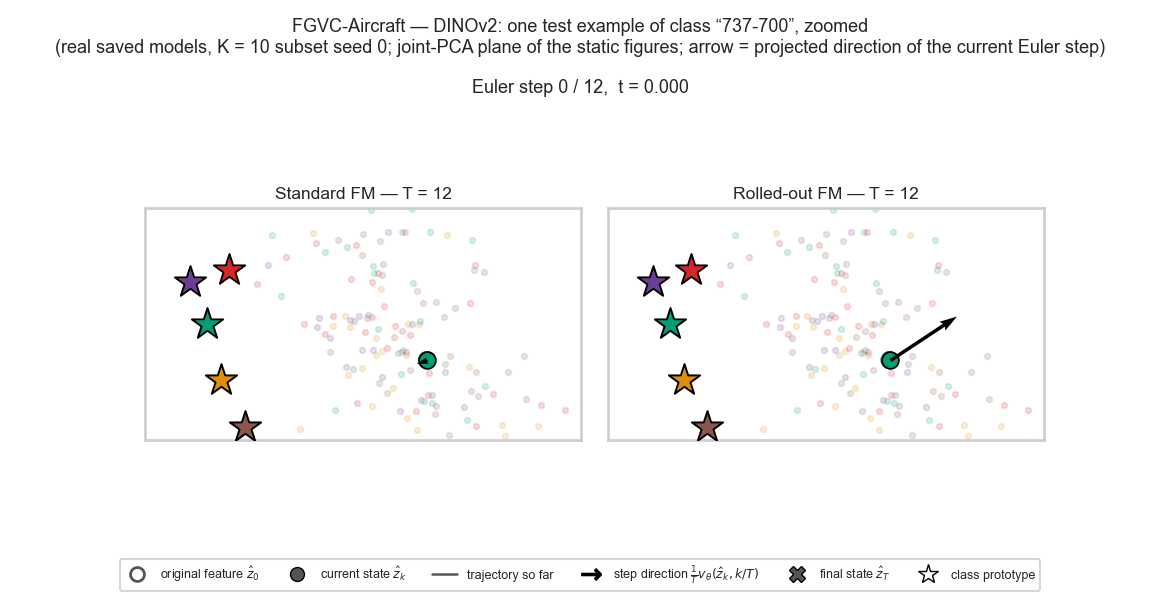

[OK] example 1: class “A320” -> results\figures\stage2_flow_anim_fgvc_aircraft_dinov2_vits14_T12_ex1.gif



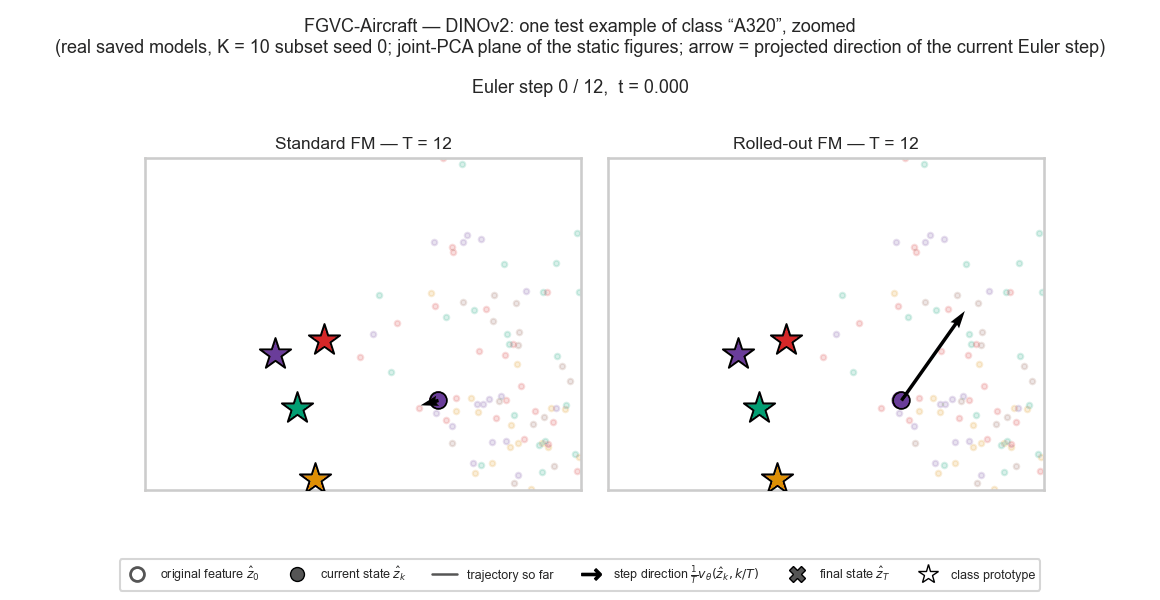

[OK] example 2: class “A340-200” -> results\figures\stage2_flow_anim_fgvc_aircraft_dinov2_vits14_T12_ex2.gif



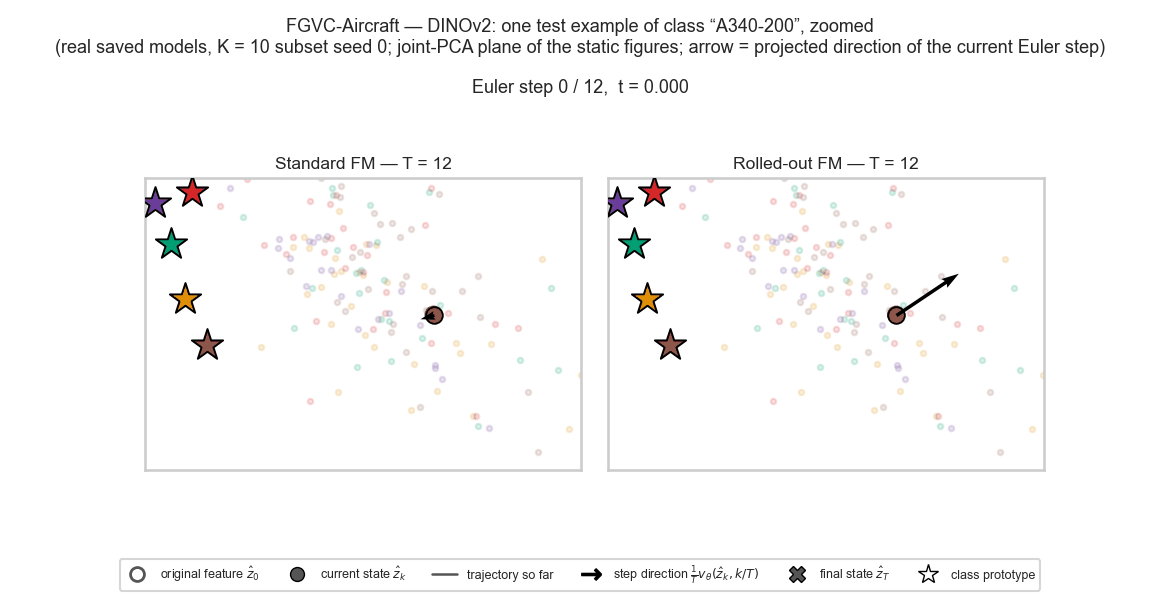

[OK] example 3: class “DHC-1” -> results\figures\stage2_flow_anim_fgvc_aircraft_dinov2_vits14_T12_ex3.gif



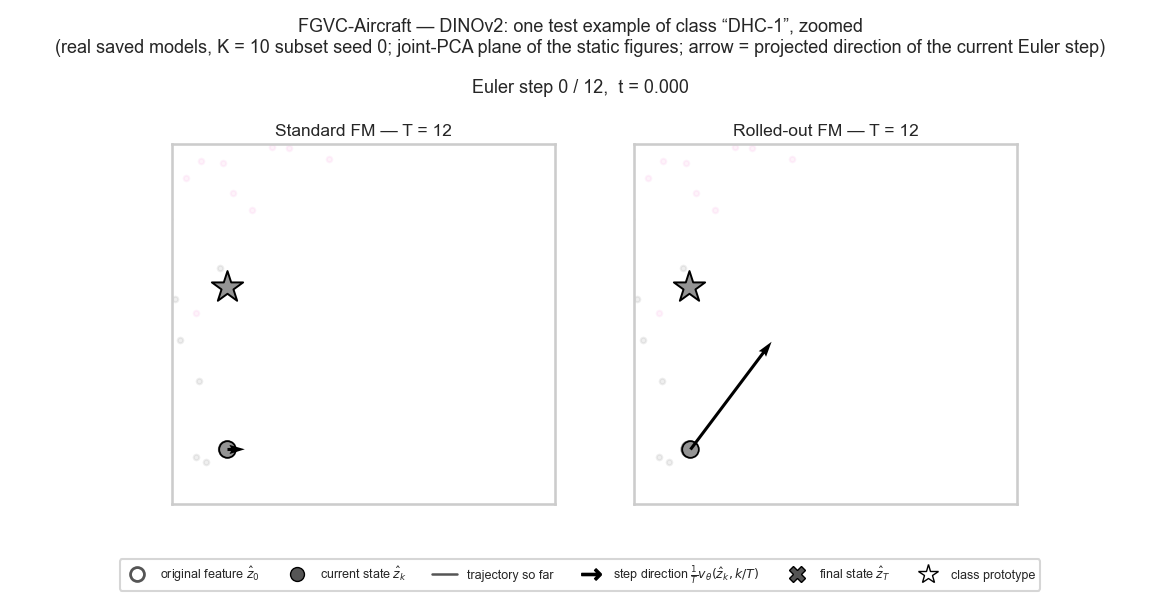

In [14]:
import base64

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.lines import Line2D
from IPython.display import HTML

sys.path.insert(0, str(REPO / "scripts"))
from make_figures_stage2 import REP_T, _joint_pca, _rep_setting
from src.visualize import class_palette, dataset_label, encoder_label

ANIM_DS, ANIM_ENC, ANIM_TARGET = "fgvc_aircraft", "dinov2_vits14", "image_prototype"

# Same selection code path as the static figures: classes, examples, features,
# transported sets, prototypes, and the two trained models of this setting.
(classes, idx, X, Xstd, Xroll, protos, y, sel_names,
 std_head, roll_head) = _rep_setting(ANIM_DS, ANIM_ENC, ANIM_TARGET)

# Same 4 examples as the static trajectory figure (same rng, same rule).
rng = np.random.default_rng(0)
picked_classes = rng.choice(len(classes), size=4, replace=False)
ex = [int(np.flatnonzero(y == c)[0]) for c in picked_classes]

# Real Euler states from the saved networks (transport() runs under no_grad).
_, traj_std = std_head.transport(X[ex], REP_T, return_traj=True)   # [T+1, 4, 384]
_, traj_roll = roll_head.transport(X[ex], REP_T, return_traj=True)

# ---- programmatic verification (all against the real pipeline) ----
z0 = F.normalize(X[ex].float(), dim=-1)
assert traj_std.shape[0] == REP_T + 1 and traj_roll.shape[0] == REP_T + 1
assert torch.allclose(traj_std[0], z0) and torch.allclose(traj_roll[0], z0)
assert torch.allclose(traj_std[0], traj_roll[0])
# final states match the transported features the feature-comparison figure uses
assert torch.allclose(traj_std[-1], Xstd[ex], atol=1e-5)
assert torch.allclose(traj_roll[-1], Xroll[ex], atol=1e-5)
# both models were trained toward identical prototypes; each example's target is
# its true class's prototype
assert torch.allclose(std_head.prototypes.cpu(), roll_head.prototypes.cpu(), atol=1e-6)
assert torch.allclose(protos, std_head.prototypes.cpu()[classes], atol=1e-6)
assert not traj_std.requires_grad and not traj_roll.requires_grad  # no gradients

# One PCA, fitted exactly as in the static figures (jointly to all compared
# sets + prototypes), transforms background, prototypes, and every frame.
pca, (bg_xy, _, _, proto_xy) = _joint_pca([X.numpy(), Xstd.numpy(), Xroll.numpy(),
                                           protos.numpy()])
txy_std = np.stack([pca.transform(traj_std[:, i].numpy()) for i in range(len(ex))])
txy_roll = np.stack([pca.transform(traj_roll[:, i].numpy()) for i in range(len(ex))])

print(f"[OK] {len(ex)} examples loaded (classes: "
      f"{', '.join(sel_names[int(y[e])] for e in ex)})")
print(f"[OK] {REP_T + 1} Euler states per trajectory")
print("[OK] shared PCA transform (fitted once, jointly, as in the static figures)")
print("[OK] first states = normalized pipeline inputs; final states match the "
      "transported features of the feature-comparison figure")
print("[OK] no gradients during trajectory generation")

palette = class_palette(len(sel_names))  # shared with every feature/traj figure
LEGEND = [
    Line2D([], [], marker="o", ls="", ms=10, mfc="none", mec="#555555", mew=2,
           label=r"original feature $\hat{z}_0$"),
    Line2D([], [], marker="o", ls="", ms=10, color="#555555", mec="black",
           label=r"current state $\hat{z}_k$"),
    Line2D([], [], color="#555555", lw=1.8, label="trajectory so far"),
    Line2D([], [], marker=r"$\rightarrow$", ls="", ms=14, color="black",
           label=r"step direction $\frac{1}{T}v_\theta(\hat{z}_k, k/T)$"),
    Line2D([], [], marker="X", ls="", ms=11, color="#555555", mec="black",
           label=r"final state $\hat{z}_T$"),
    Line2D([], [], marker="*", ls="", ms=15, mfc="white", mec="black",
           label="class prototype")]


def animate_example(i):
    """One zoomed two-panel animation (Standard | Rolled-out) for example i;
    returns the saved GIF path. Axis limits fixed to this example's trajectories
    + its prototype, identical in both panels and across all frames."""
    e = ex[i]
    cls = int(y[e])
    c = palette[cls]
    pts = np.concatenate([txy_std[i], txy_roll[i], proto_xy[cls:cls + 1]])
    lo, hi = pts.min(0), pts.max(0)
    pad = 0.20 * max(hi - lo)
    xlim, ylim = (lo[0] - pad, hi[0] + pad), (lo[1] - pad, hi[1] + pad)

    fig, axes = plt.subplots(1, 2, figsize=(11.6, 6.0))
    fig.subplots_adjust(top=0.76, bottom=0.16, wspace=0.06)
    panels = []
    for ax, title, txy in ((axes[0], f"Standard FM — T = {REP_T}", txy_std[i]),
                           (axes[1], f"Rolled-out FM — T = {REP_T}", txy_roll[i])):
        for j in sorted(np.unique(y)):   # background clipped by the zoom window
            m = y == j
            ax.scatter(bg_xy[m, 0], bg_xy[m, 1], s=16, alpha=0.15, color=palette[j])
            ax.scatter(proto_xy[j, 0], proto_xy[j, 1], marker="*", s=560,
                       color=palette[j], edgecolors="black", linewidths=1.4, zorder=5)
        ax.scatter(*txy[0], s=120, facecolors="none", edgecolors=c,
                   linewidths=2.2, zorder=6)                     # hollow z0
        trail, = ax.plot([], [], color=c, lw=2.0, alpha=0.95, zorder=4)
        cur, = ax.plot([], [], marker="o", ms=12, color=c, mec="black", mew=1.3,
                       zorder=7)
        arrow = ax.quiver([txy[0, 0]], [txy[0, 1]], [0.0], [0.0], angles="xy",
                          scale_units="xy", scale=1.0, color="black",
                          width=0.008, zorder=8)
        fin = ax.scatter([], [], marker="X", s=150, color=c, edgecolors="black",
                         linewidths=1.3, zorder=9, visible=False)
        ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        ax.set_title(title, fontsize=12.5)
        panels.append({"trail": trail, "cur": cur, "arrow": arrow, "fin": fin,
                       "txy": txy})

    step_txt = fig.text(0.5, 0.845, "", ha="center", fontsize=13)
    fig.legend(handles=LEGEND, loc="lower center", bbox_to_anchor=(0.5, 0.005),
               ncol=6, fontsize=9, frameon=True)
    fig.suptitle(f"{dataset_label(ANIM_DS)} — {encoder_label(ANIM_ENC, short=True)}: "
                 f"one test example of class \u201c{sel_names[cls]}\u201d, zoomed"
                 f"\n(real saved models, K = 10 subset seed 0; joint-PCA plane of "
                 f"the static figures; arrow = projected direction of the current "
                 f"Euler step)", y=0.97, fontsize=13)

    def draw(k):
        for p in panels:
            xy = p["txy"]
            p["trail"].set_data(xy[:k + 1, 0], xy[:k + 1, 1])
            p["cur"].set_data([xy[k, 0]], [xy[k, 1]])
            if k < REP_T:                 # the step about to be taken
                p["arrow"].set_offsets(xy[k:k + 1])
                p["arrow"].set_UVC([xy[k + 1, 0] - xy[k, 0]],
                                   [xy[k + 1, 1] - xy[k, 1]])
                p["arrow"].set_visible(True)
            else:
                p["arrow"].set_visible(False)
            p["fin"].set_visible(k == REP_T)
            if k == REP_T:
                p["fin"].set_offsets(xy[-1:])
        step_txt.set_text(f"Euler step {k} / {REP_T},  t = {k / REP_T:.3f}")
        return []

    frames = [0] * 3 + list(range(1, REP_T)) + [REP_T] * 4   # hold first & last
    anim = FuncAnimation(fig, draw, frames=frames, interval=600, blit=False)
    path = (REPO / "results" / "figures" /
            f"stage2_flow_anim_{ANIM_DS}_{ANIM_ENC}_T{REP_T}_ex{i}.gif")
    try:
        anim.save(path, writer=PillowWriter(fps=2))
    except Exception as err:
        print(f"[WARN] GIF export failed for example {i} ({err}); "
              f"falling back to the inline JS player")
        display(HTML(anim.to_jshtml()))
        path = None
    plt.close(fig)
    return path, cls


for i in range(len(ex)):
    gif, cls = animate_example(i)
    if gif is not None:
        print(f"[OK] example {i}: class \u201c{sel_names[cls]}\u201d -> "
              f"{gif.relative_to(REPO)}")
        # embed the GIF bytes directly, so the animation plays in any notebook
        # viewer (VS Code included) without JavaScript and without path issues
        b64 = base64.b64encode(gif.read_bytes()).decode("ascii")
        display(HTML(f'<img src="data:image/gif;base64,{b64}" width="920"/>'))

**Reading the animations.** The markers follow **real states produced by the learned velocity networks** — nothing is a hand-drawn interpolation. In each pair of panels both models start from the identical normalized test feature; the difference is purely the training objective: **Standard FM** was supervised on velocities at random points along the ideal straight interpolation path (which is why its arrows stay nearly parallel and its path runs almost straight), while **Rolled-out FM** was trained through its own self-generated $T$-step sequence with a loss only on the final transported state — its velocity field is free to curve, and the arrows visibly change direction between steps.

Two caveats for honest reading: the actual transport happens in the original **384-dimensional DINOv2 feature space**; the zoomed PCA view is a qualitative 2-D projection of that motion, so projected path length, curvature, arrow direction, and distances must not be read as high-dimensional measurements (the drawn arrow is the projection of the true step $\frac{1}{T}v_\theta(\hat{z}_k, k/T)$ into the plane). What the animations *are* meant to convey is mechanism: how $T$ small Euler updates $\hat{z}_{k+1} = \hat{z}_k + \frac{1}{T}v_\theta(\hat{z}_k, k/T)$ accumulate into the final transported representation that the cosine/prototype rule then classifies.

### Optional exploration ‡ — reverse feature-space integration from the prototypes

The specification encourages exploring the learned flow **in the reverse direction**, starting from the class prototypes, and comparing samples and prototypes at intermediate flow times. We integrate the learned field backward from $t = 1$ to $t = 0$ with explicit Euler:

$$\hat{z}_{k-1} = \hat{z}_k - \tfrac{1}{T}\, v_\theta\!\left(\hat{z}_k, \tfrac{k}{T}\right), \qquad k = T, T{-}1, \dots, 1,$$

starting from each class prototype as $\hat{z}_T$ (first velocity evaluation at $t = 1$, as canonical reverse integration requires). This is **approximate backward integration of the learned continuous field** — not the algebraic inverse of the discrete forward-Euler map — and it is fully deterministic: this FM head is not a generative model, so one prototype yields exactly one reverse trajectory (no noise is injected). We run it on **both branches** at the representative setting ($K = 10$, subset seed 0, $T = 12$, both training modes): the spec branch (FGVC-Aircraft / DINOv2, image prototypes) and the ‡ CLIP branch (FGVC-Aircraft / CLIP RN50, **text** prototypes), where backward integration additionally has to re-cross the image–text modality gap. Same classes, examples, colours and **the same jointly fitted PCA plane** as the forward figures (fitted once, never refit). No model was retrained and no published result changes.

**Why the reverse arrows do not retrace the forward arrows.** The reverse paths are *not* the forward paths played backwards — and should not be: (i) reverse integration starts *exactly at the prototype*, whereas forward trajectories start at individual test features and end only *near* it; (ii) reverse Euler evaluates the field at different states and times than the forward steps did; (iii) near $t = 1$ the standard-FM field is a *conditional average* over the whole class (§5), so its backward path follows the class-mean corridor rather than any single sample's path. To make the comparison visible rather than implicit, each panel also draws the **forward class-centroid path** (dashed, faint) in the same plane.

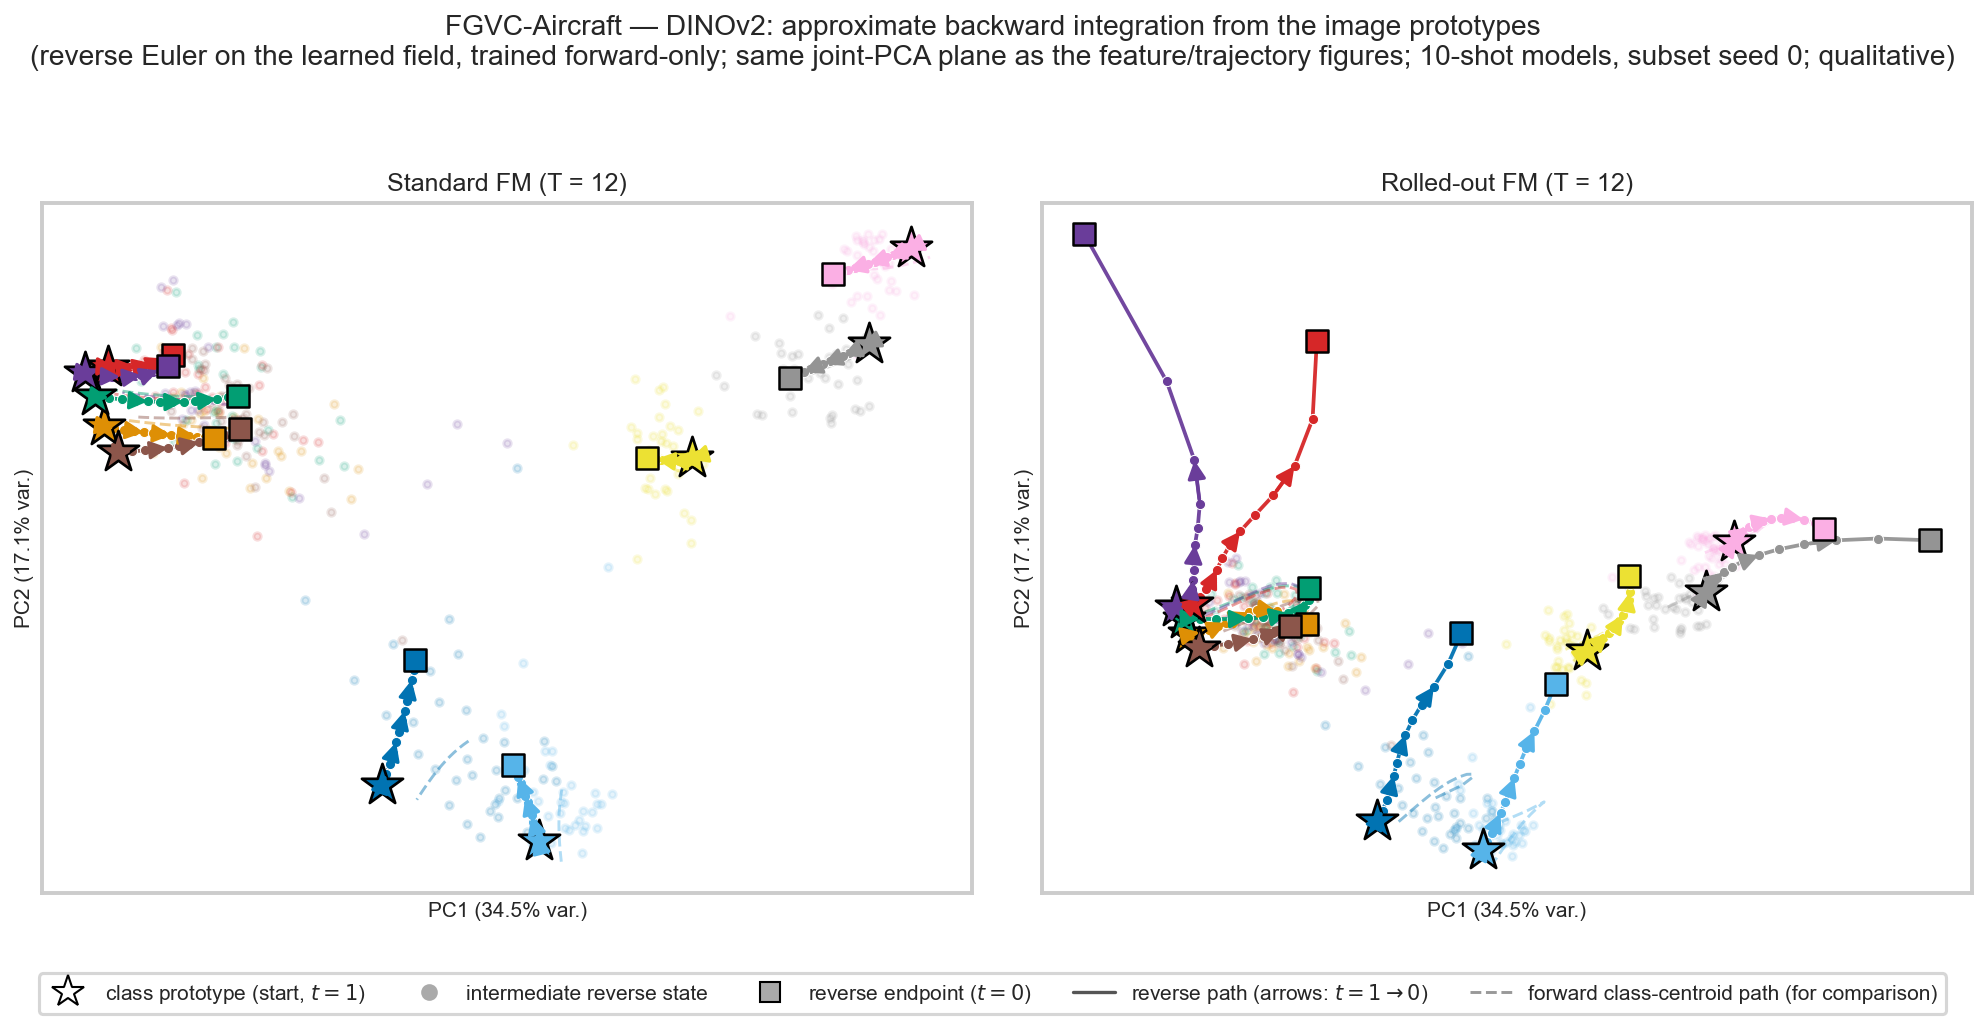

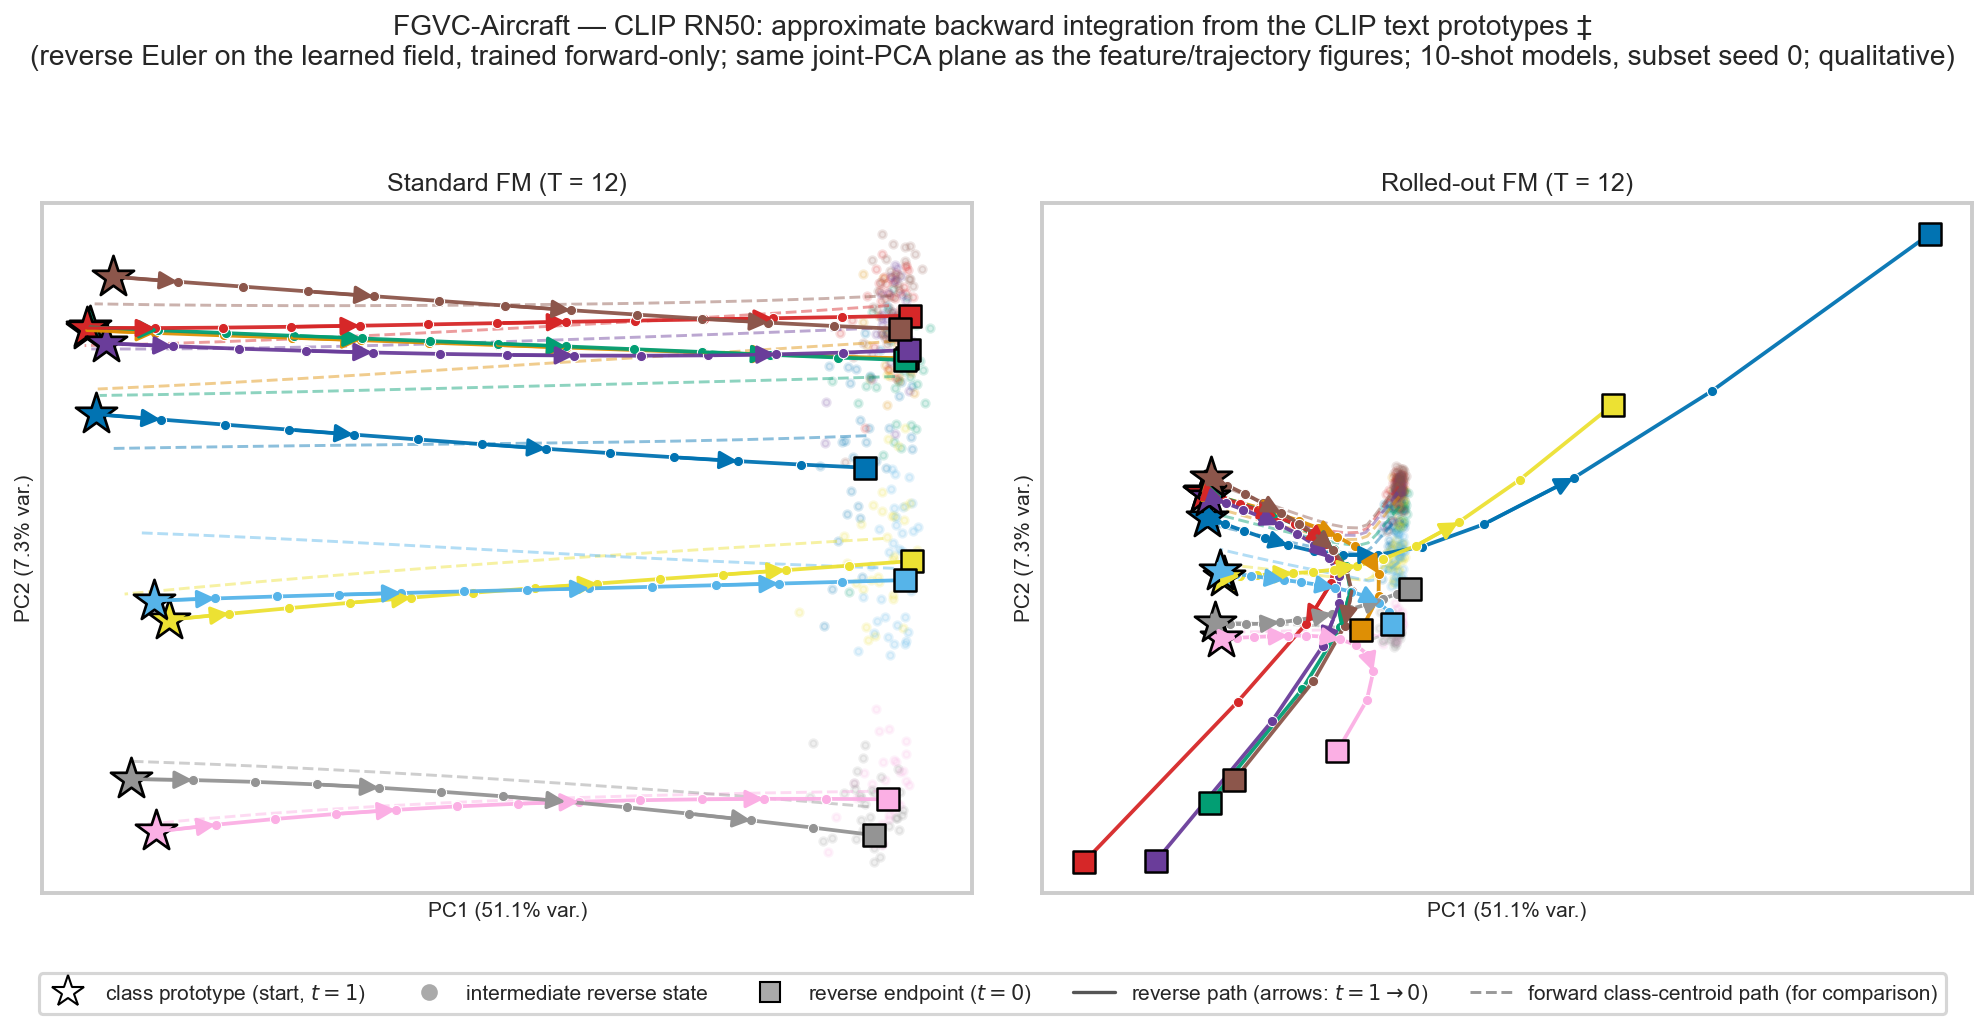

In [15]:
from src.visualize import head_label

for name in ("stage2_reverse_flow_fgvc_aircraft_dinov2_vits14_image_prototype_T12.png",
             "stage2_reverse_flow_fgvc_aircraft_clip_rn50_clip_text_T12.png"):
    display(Image(str(REPO / "results" / "figures" / name), width=980))

**Samples vs prototypes at matching intermediate times.** For each selected class and every Euler time $t = k/T$: the centroid of that class's selected test samples along the **forward** flow, compared against the **reverse** trajectory that started at that class's prototype — cosine similarity ($L_2$ secondary), computed in the full feature space (384-d DINOv2 / 1024-d CLIP), *not* in the PCA plane. The curves show **mean ± sample std across the ten selected classes**; per-class raw values are in `results/metrics/stage2_reverse_intermediate_*.csv`.

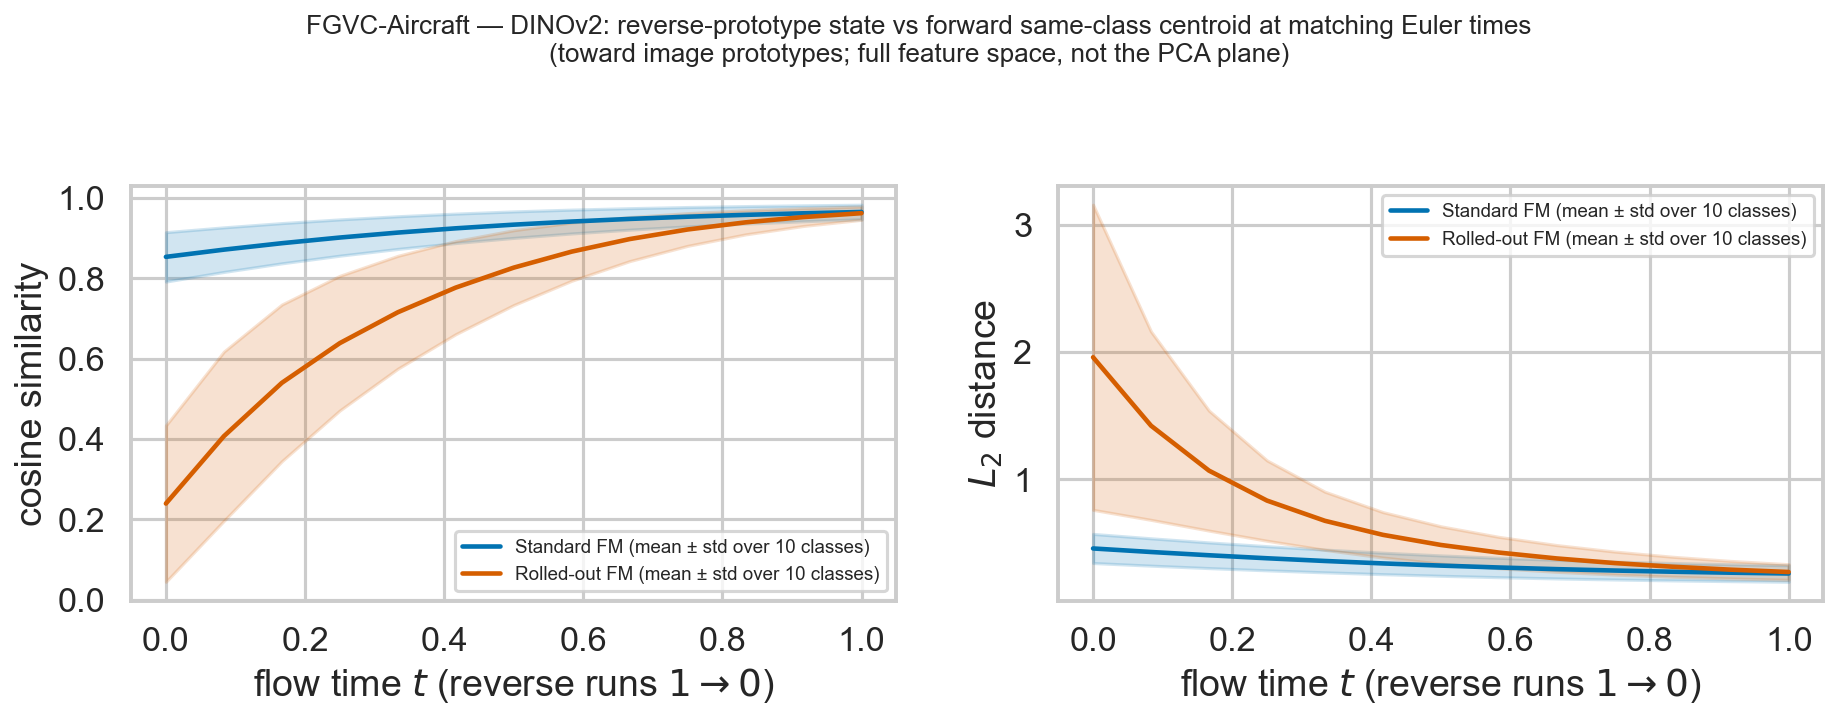

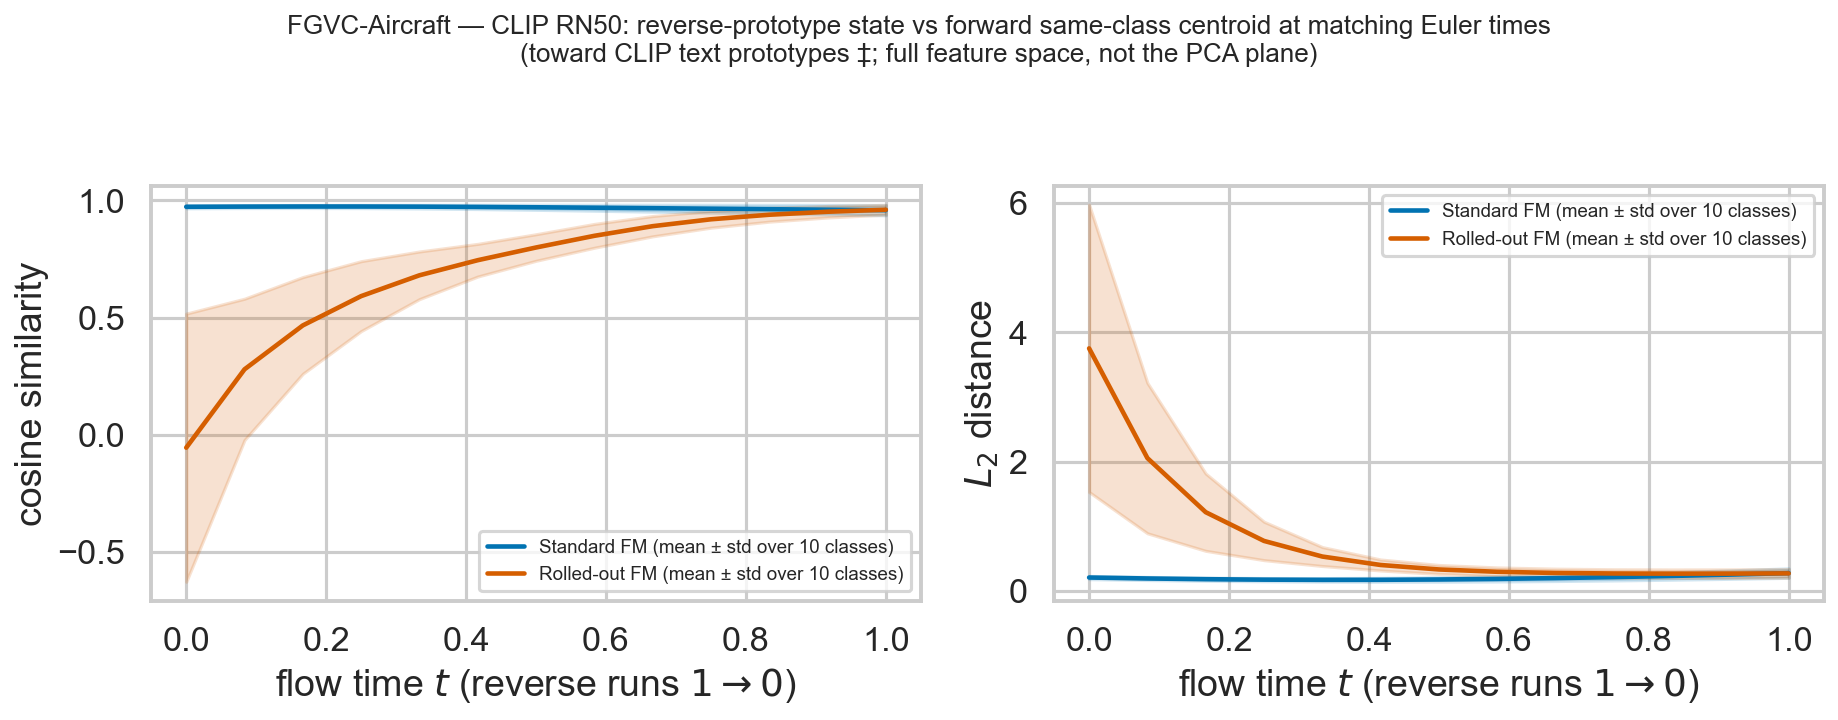

At t = 0 — reverse endpoint vs the class's original-feature centroid (mean ± sample std over the 10 selected classes):


,setting,head,cosine mean,cosine std,L2 mean
0,DINOv2 → image prototypes,Rolled-out FM,0.24,1.95e-01,1.96
1,DINOv2 → image prototypes,Standard FM,0.85,6.10e-02,0.46
2,CLIP RN50 → text prototypes ‡,Rolled-out FM,-0.06,5.73e-01,3.75
3,CLIP RN50 → text prototypes ‡,Standard FM,0.97,6.00e-03,0.21


In [16]:
for name in ("stage2_reverse_intermediate_fgvc_aircraft_dinov2_vits14_image_prototype_T12.png",
             "stage2_reverse_intermediate_fgvc_aircraft_clip_rn50_clip_text_T12.png"):
    display(Image(str(REPO / "results" / "figures" / name), width=920))

rows = []
for tag, label in (("fgvc_aircraft_dinov2_vits14_image_prototype_T12", "DINOv2 → image prototypes"),
                   ("fgvc_aircraft_clip_rn50_clip_text_T12", "CLIP RN50 → text prototypes ‡")):
    d = pd.read_csv(REPO / "results" / "metrics" / f"stage2_reverse_intermediate_{tag}.csv")
    e = d[d["t"] == 0].groupby("head")[["cosine", "l2"]].agg(["mean", "std"])
    for head in e.index:
        rows.append({"setting": label, "head": head_label(head),
                     "cosine mean": round(e.loc[head, ("cosine", "mean")], 3),
                     "cosine std": round(e.loc[head, ("cosine", "std")], 3),
                     "L2 mean": round(e.loc[head, ("l2", "mean")], 3)})
print("At t = 0 — reverse endpoint vs the class's original-feature centroid "
      "(mean ± sample std over the 10 selected classes):")
display(pd.DataFrame(rows))

**Reverse-flow Top-1 (%) — what exactly these percentages are.** Each number below is **top-1 accuracy on the complete official test split** (all 3,333 FGVC-Aircraft test images, all 100 classes), from a **single deterministic inference pass** on the representative $K = 10$, seed-0 model — so, unlike the accuracy tables in §3, these carry **no ± spread: they are not averaged over runs or seeds** (the only averaging anywhere in this section is the cosine/$L_2$ table above, which averages over the ten *selected classes*). Four columns per training mode:

| Column | What is measured |
|---|---|
| **Stage-1 prototype baseline** | untouched features classified against the prototypes — the reference the FM layer must beat |
| **Forward FM (published)** | the §3 grid number for this exact cell, recomputed here; the generator asserts it still matches `runs_stage2.csv` |
| **Round-trip** | transport every test feature forward to $t = 1$, integrate it back to $t = 0$, classify the reconstruction with the Stage-1 rule — *how much class information survives a full forward-then-backward traversal* |
| **Reverse-endpoint classifier** | integrate **all 100 class prototypes** backward to $t = 0$ and use those endpoints as class representatives for the **original** features — *whether the backward images of the prototypes are still usable class descriptions* |

Both reverse read-outs are label-free inference on already-trained models; no training, no selection, nothing published changes.

In [17]:
frames = []
for tag, label in (("fgvc_aircraft_dinov2_vits14_image_prototype_T12", "DINOv2 → image prototypes"),
                   ("fgvc_aircraft_clip_rn50_clip_text_T12", "CLIP RN50 → text prototypes ‡")):
    d = pd.read_csv(REPO / "results" / "metrics" / f"stage2_reverse_top1_{tag}.csv")
    d.insert(0, "setting", label)
    d["head"] = d["head"].map(head_label)
    frames.append(d)
acc = pd.concat(frames, ignore_index=True)
for c in acc.columns[2:]:
    acc[c] = (100 * acc[c]).round(2)
acc.columns = ["setting", "head", "Stage-1 prototype baseline", "Forward FM (published)",
               "Round-trip (fwd → rev)", "Reverse-endpoint classifier"]
display(acc)
print("Top-1 (%) on the complete official test split; single deterministic runs "
      "(K = 10, seed 0, T = 12) — no averaging over runs or seeds.")

,setting,head,Stage-1 prototype baseline,Forward FM (published),Round-trip (fwd → rev),Reverse-endpoint classifier
0,DINOv2 → image prototypes,Standard FM,29.13,43.77,31.17,25.68
1,DINOv2 → image prototypes,Rolled-out FM,29.13,45.27,26.01,11.07
2,CLIP RN50 → text prototypes ‡,Standard FM,17.04,21.99,16.89,26.40
3,CLIP RN50 → text prototypes ‡,Rolled-out FM,17.04,22.32,6.27,3.45


Top-1 (%) on the complete official test split; single deterministic runs (K = 10, seed 0, T = 12) — no averaging over runs or seeds.


**What the actual results show.**

*Spec branch (DINOv2 → image prototypes).* **Standard FM** integrates backward gracefully: reverse paths stay inside the data region and hug the forward class-centroid paths; the reverse state tracks the forward same-class centroid at every intermediate time (cosine 0.85 ± 0.06 at $t = 0$); the round trip *preserves* class information (31.17% vs the 29.13% untouched-feature baseline); and the backward images of the prototypes remain serviceable class representatives (25.68%). This is what per-path velocity supervision buys — the field carries meaningful values at every $(z, t)$, so it can be traversed in either direction. **Rolled-out FM** collapses in reverse: paths shoot outside the data, similarity falls to 0.24 ± 0.20, the round trip *loses* information (26.01%, below baseline) and the reverse-endpoint classifier drops to 11.07%. Its endpoint-only objective never constrains the field along the path — the composed forward map is accurate, but the field it is built from is not individually meaningful.

*CLIP branch ‡ (text prototypes).* The same split appears, more extremely, plus one genuinely striking result. Standard FM's reverse trajectories **cross the modality gap backward**: starting at the isolated text prototypes they travel into the image-feature cloud and land essentially on the class centroids (cosine **0.973 ± 0.006**, the tightest agreement anywhere in this section). And the reverse-endpoint classifier reaches **26.40%** — *above* the forward FM (21.99%) and far above zero-shot CLIP (17.04%). Reading it carefully: backward integration turns each text prototype into an **image-space** class representative, and classifying image features against those is markedly better than classifying them against the text prototypes directly — a concrete, measured demonstration that the learned flow encodes the modality gap in a usable way. (It is not a "better classifier" claim for the pipeline: the flow was trained with $K = 10$ labels per class, so this belongs beside the other supervised ‡ numbers, not beside zero-shot.) Rolled-out FM again fails in reverse — cosine −0.06 ± 0.57, round trip 6.27%, reverse endpoints 3.45%. Note also that the CLIP round trip is slightly *below* baseline even for standard FM (16.89% vs 17.04%): traversing there and back across the modality gap costs a little, while the one-way backward map is what carries the value.

Across both branches, the reverse direction is an independent, training-free confirmation of the §6 mechanism story: **standard FM learns a field that is meaningful everywhere; rolled-out FM learns only a good composed endpoint map.**

**Limitations (read before over-interpreting):** the network was trained in the **forward** direction only; rolled-out training never directly supervised any reverse trajectory; canonical reverse integration requires evaluating at $t = 1$, a time the forward Euler rollout never evaluates (it stops at $(T{-}1)/T$); reverse trajectories need **not** recover real samples — this is reverse *feature-space* exploration, not image generation; the learned map is deterministic and may be many-to-one, so nothing guarantees bijectivity; the Top-1 read-outs are single deterministic runs on one representative setting (no seed spread); and the trajectory plots are qualitative 2-D PCA projections (all metrics are computed in the full feature space).

## 6 · Discussion

The observations below are read directly off §3–§5. Every Stage-2 number appears in the generated tables and is re-derived from raw artifacts by the repro check; the Stage-1 reference values used for context (probe accuracy, validation headroom) are computed live from the Stage-1 `runs.csv` in the cell below, so this notebook remains self-contained.

**1 · The FM layer pays where Stage 1 measured headroom, and only there.** Stage 1's handoff table quantified how much accuracy the class-mean prototype leaves on the table relative to a trained boundary on the same features (validation headroom). The Stage-2 gains line up with it — a consistent ordering across the three dataset–encoder settings we have, which is suggestive rather than a statistical claim at $n = 3$ settings: FGVC-Aircraft/DINOv2 — the setting with by far the largest headroom (35.7 validation points) — gains **+10.4 to +23.2 points** (3/3 seeds at every K), lifting the full-split prototype pipeline from 34.4% to 57.6%; FGVC-Aircraft/ResNet-18 (moderate headroom) gains +1.6 to +6.7 with standard FM (3/3 seeds); DTD/ResNet-18 (smallest headroom, 5.3 validation points) gains only +0.5 to +0.8 at full — and *loses* 2.4–12.9 points in the low-shot settings, 0/3 seeds in favour. The mechanism is the one §5 shows geometrically: a trained nonlinear transport re-introduces discriminative structure that the class-mean estimator discards. Where the representation is rich and classes separable (DINOv2 on fine-grained aircraft), there is a lot to re-introduce; where classes are heavily entangled (textures), the learned basins misroute test features and transport *creates* errors — increasingly so at small K, where the 5–10 images per class that define both the prototypes and the flow cannot pin down basin boundaries.

**2 · Standard FM is the better or equal training mode on the spec branch.** On all three image-prototype settings (DTD: standard loses less; FGVC/ResNet-18: standard +1.6 to +6.7 vs rollout −0.2 to +1.4; DINOv2: statistically indistinguishable at K ∈ {5,10} — at matched T, rollout is nominally ahead in the two T = 12 cells and behind in the two T = 4 cells, all well within the paired spreads — and standard ahead by 2.2–3.0 points at full). Rolled-out training also produced all three genuine training divergences (§4). Both facts have one root: the rolled-out objective constrains only the *endpoint* of the composed T-step map and provides no supervision along the path, so the learned field is freer to become degenerate; standard FM's per-point velocity supervision acts as a regularizer along the entire trajectory. The one place rolled-out training wins decisively is the CLIP‡ branch at full split on FGVC-Aircraft (+14.5 vs +6.9 at T = 4) — transporting across the image–text modality gap is precisely the regime where the ideal straight-line velocity field is most misspecified, and an endpoint-only objective is free to find a better curved transport (§5's trajectory figures show the curvature directly).

**3 · T barely matters for standard FM.** The two standard rows of every setting share one network; going from 4 to 12 Euler steps changes accuracy by less than 0.7 points (both signs occur). The learned velocity field is smooth enough that integration error is not the binding constraint. For rolled-out models T is a training choice, and on the image branch T = 12 is never better than T = 4 by more than noise — deeper backprop-through-time buys no measurable benefit there (all three divergences were rolled-out runs at K = full: two at T = 4, one at T = 12).

**4 · The CLIP‡ extension: labels + transport beat zero-shot everywhere, with the caveat stated in §3.2.** Supervised transport toward text prototypes exceeds the zero-shot reference in every cell (from +1.5 at FGVC 5-shot to +23.9 on DTD full). These deltas bundle the value of K labels with the value of transport and therefore say nothing about the FM layer in isolation; they do show that a frozen CLIP image encoder plus a small trained transport is a viable low-shot classifier, and that the modality gap is learnable to cross.

**5 · What this hands Stage 3.** Stage 3 places the FM module *before* a linear classifier and trains both jointly with cross-entropy. Stage 2's lessons carry directly: (i) the transport map has real discriminative capacity (DINOv2 +23), but (ii) even the best FM-to-prototype pipeline (57.6%) remains 9.6 points below the Stage-1 linear probe on the same features (67.2%, verified below) — prototype-targeted transport alone does not recover a trained boundary; and (iii) per-path supervision (standard) is the stable optimization regime, endpoint-only objectives (which Stage 3's CE-through-the-module resembles) need the stability safeguards §4 established.

In [18]:
# Stage-1 reference values quoted above, computed live from Stage-1 artifacts
# so this notebook is self-contained.
r1 = pd.read_csv(REPO / "results" / "metrics" / "runs.csv")
full = r1[r1["k_shot"] == "full"]
rows = []
for ds, enc in (("dtd", "resnet18"), ("fgvc_aircraft", "dinov2_vits14")):
    g = full[(full["dataset"] == ds) & (full["encoder"] == enc)]
    probe_val = g[g["head"] == "linear_probe"]["val_acc"].mean()
    proto_val = float(g[g["head"] == "image_prototype"]["val_acc"].iloc[0])
    probe_test = g[g["head"] == "linear_probe"]["test_acc"].mean()
    rows.append({"Dataset / encoder": f"{ds} / {enc}",
                 "Stage-1 probe, full (test %)": round(100 * probe_test, 2),
                 "Validation headroom probe − prototype (pts)":
                     round(100 * (probe_val - proto_val), 2)})
print("Stage-1 reference values used in the discussion (from runs.csv):")
display(pd.DataFrame(rows))

s2best = pd.read_csv(REPO / "results" / "metrics" / "summary_stage2.csv")
b = s2best[(s2best["dataset"] == "fgvc_aircraft") & (s2best["encoder"] == "dinov2_vits14")
           & (s2best["k_shot"] == "full")]["mean_acc"].max()
probe = full[(full["dataset"] == "fgvc_aircraft") & (full["encoder"] == "dinov2_vits14")
             & (full["head"] == "linear_probe")]["test_acc"].mean()
print(f"Best FM-to-prototype (FGVC/DINOv2, full): {100*b:.2f}%  vs  "
      f"Stage-1 probe: {100*probe:.2f}%  ->  gap {100*(probe-b):.2f} pts")

Stage-1 reference values used in the discussion (from runs.csv):


,Dataset / encoder,"Stage-1 probe, full (test %)",Validation headroom probe − prototype (pts)
0,dtd / resnet18,62.84,5.34
1,fgvc_aircraft / dinov2_vits14,67.21,35.70


Best FM-to-prototype (FGVC/DINOv2, full): 57.59%  vs  Stage-1 probe: 67.21%  ->  gap 9.62 pts


### Limitations

- **$n = 3$ runs per setting.** Spreads are sample standard deviations; no confidence intervals are quoted. Per-seed pairing (where genuine) is stated with sign counts instead.
- **At K = full the image-branch deltas are unpaired** — all three FM initialization seeds are compared against the single deterministic full-split baseline, so their spread measures FM training stochasticity only. The CLIP‡ deltas are never paired (single zero-shot reference).
- **The CLIP‡ branch cannot isolate the FM effect.** Its reference consumes zero labeled images while FM consumes K per class; a labeled CLIP image-prototype baseline is excluded by the Stage-1 protocol (CLIP is restricted to the zero-shot branch). The ‡ deltas conflate "value of K labels" with "value of transport".
- **No hyperparameter search** — the Stage-1 probe recipe was adopted verbatim a priori. Better FM numbers are plausibly reachable — particularly for rolled-out training, whose divergences suggest the shared learning rate sits near its stability edge for backprop-through-T — but tuning was out of scope (spec) and would have to use validation data only.
- **Checkpoint = minimum-training-loss epoch, uniformly** (the §4 contingency; a training-set-only criterion — no validation or test data enters any Stage-2 selection). The 1.05× trigger threshold proved tight for standard FM's stochastic per-epoch loss (most flags were benign last-epoch noise); the uniform fallback absorbs both benign and genuine cases without discretion.
- **2-D projections are qualitative**; the joint-PCA plane explains only part of the variance and trajectory geometry off-plane is invisible.

### Deviations from, and extensions beyond, the specification

| Item | Status | Note |
|---|---|---|
| FM on $L_2$-normalized features | **disclosed deviation** | fixed a priori (ADR 0007 §3); the cosine classifier acts on the sphere; T = 0 reproduces Stage 1 exactly (§2 guard) |
| Datasets | as specified | the Stage-1 selected pair DTD + FGVC-Aircraft (ADR 0006); "same datasets as Stage 1" |
| Prototype branch | as specified + extension ‡ | spec branch = image prototypes (Stage-1 Option A selection); CLIP‡ text-prototype transport added as a marked extension |
| Velocity network / T grid / losses | as specified | MLP 2×512 SiLU, scalar t concatenated; T ∈ {4, 12}; per-sample squared $L_2$ losses |
| Training configuration | suggested-scope | Stage-1 probe recipe reused verbatim, no search |
| Checkpoint = min-training-loss epoch | **pre-registered contingency, triggered** | §4: uniform over all models after 3 rolled-out divergences on the first grid; training-set-only criterion; the first grid's numbers were never published |
| Runs / seeds / metric | as specified | Stage-1 repetition protocol mirrored exactly; top-1 on the complete official test split |
| Optional reverse-flow / intermediate-time exploration | **done** ‡ (§5c) | approximate backward integration from the prototypes + sample-vs-prototype comparison at matching times; no retraining, no published number changed |
| Raw-feature version of the full grid | extension (beyond spec) | the literal-spec formulation ($\hat{z}_0 = z$) run in full under the identical protocol (§2) — every seed, T, branch; isolates the normalization decision completely; the normalized version remains the primary result |

### Artifact paths

| Artifact | Path |
|---|---|
| Per-run and summary results | `results/metrics/runs_stage2.csv`, `summary_stage2.csv`, `raw/fm_*.npy` |
| Generated tables | `results/metrics/stage2_*_table.md` |
| FM training-loss histories (every model) | `results/artifacts/curves_stage2/*.json` |
| Trained velocity networks | `results/artifacts/fm_models/*.pt` (gitignored, regenerable via `tasks.ps1 run2`) |
| Run-0 predictions | `results/artifacts/predictions/run2_*.npz` |
| Figures | `results/figures/stage2_*.png` |

Reproduce with `tasks.ps1 run2` (grid), `tables2`, `figures2`, `notebook2`; `tasks.ps1 check` re-derives every summary number, every Δ, and every generated table from the raw artifacts and the Stage-1 `runs.csv`.

**Provenance.** This notebook re-executes only inside its repository (`alonengel/Computer-Vision-Project`, private — available on request), which carries `src/`, `config/`, the committed metrics/artifacts, and the gitignored-but-regenerable feature caches and FM checkpoints. As a standalone file it is fully *readable* — every output, table, figure and animation above is embedded — but not re-runnable; that is by design (the repo, not the notebook, is the unit of reproduction).